# HƯỚNG XỬ LÝ 2: PHÂN LOẠI MỨC ĐỘ HÀI LÒNG CỦA HÀNH KHÁCH BẰNG NEURAL NETWORK VỚI ONE-HOT ENCODING CHO `Class`
#Danh sác thành viên nhóm M3gan
| STT | Họ và tên |
| :--- | :--- |
| 1 | **Phan Cao Hiển (X)** |
| 2 | **Bùi Quốc Đạt** |
| 3 | **Nguyễn Lê Đăng Khôi** |
| 4 | **Huỳnh Khánh Nhân** |

## 1. Giới thiệu

Trong hướng xử lý này, nhóm tiếp cận bài toán **phân loại nhị phân** để dự đoán nhãn `satisfaction` của hành khách.  
Khác với hướng xử lý 1, biến `Class` **không được mã hóa thành 0, 1, 2** mà được biểu diễn bằng **One-Hot Encoding**. Cách biểu diễn này giúp giữ tính độc lập giữa các hạng vé và tránh áp đặt quan hệ thứ tự không cần thiết giữa các nhóm.

Notebook gồm hai nhánh thực nghiệm:

- **Nhánh 1:** dữ liệu **có xử lý outlier**
- **Nhánh 2:** dữ liệu **không xử lý outlier**

Trên mỗi nhánh, nhóm huấn luyện nhiều mô hình **Neural Network (MLP)** với các optimizer và activation function khác nhau để so sánh hiệu quả dự đoán. Chỉ số đánh giá chính là **Accuracy**.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
import keras
tf.keras.utils.set_random_seed(0)

In [ ]:
Airline = pd.read_csv('/content/train.csv')
Airline

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [ ]:
df=pd.read_csv('/content/test.csv')

In [ ]:
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:

Airline.shape

(103904, 25)

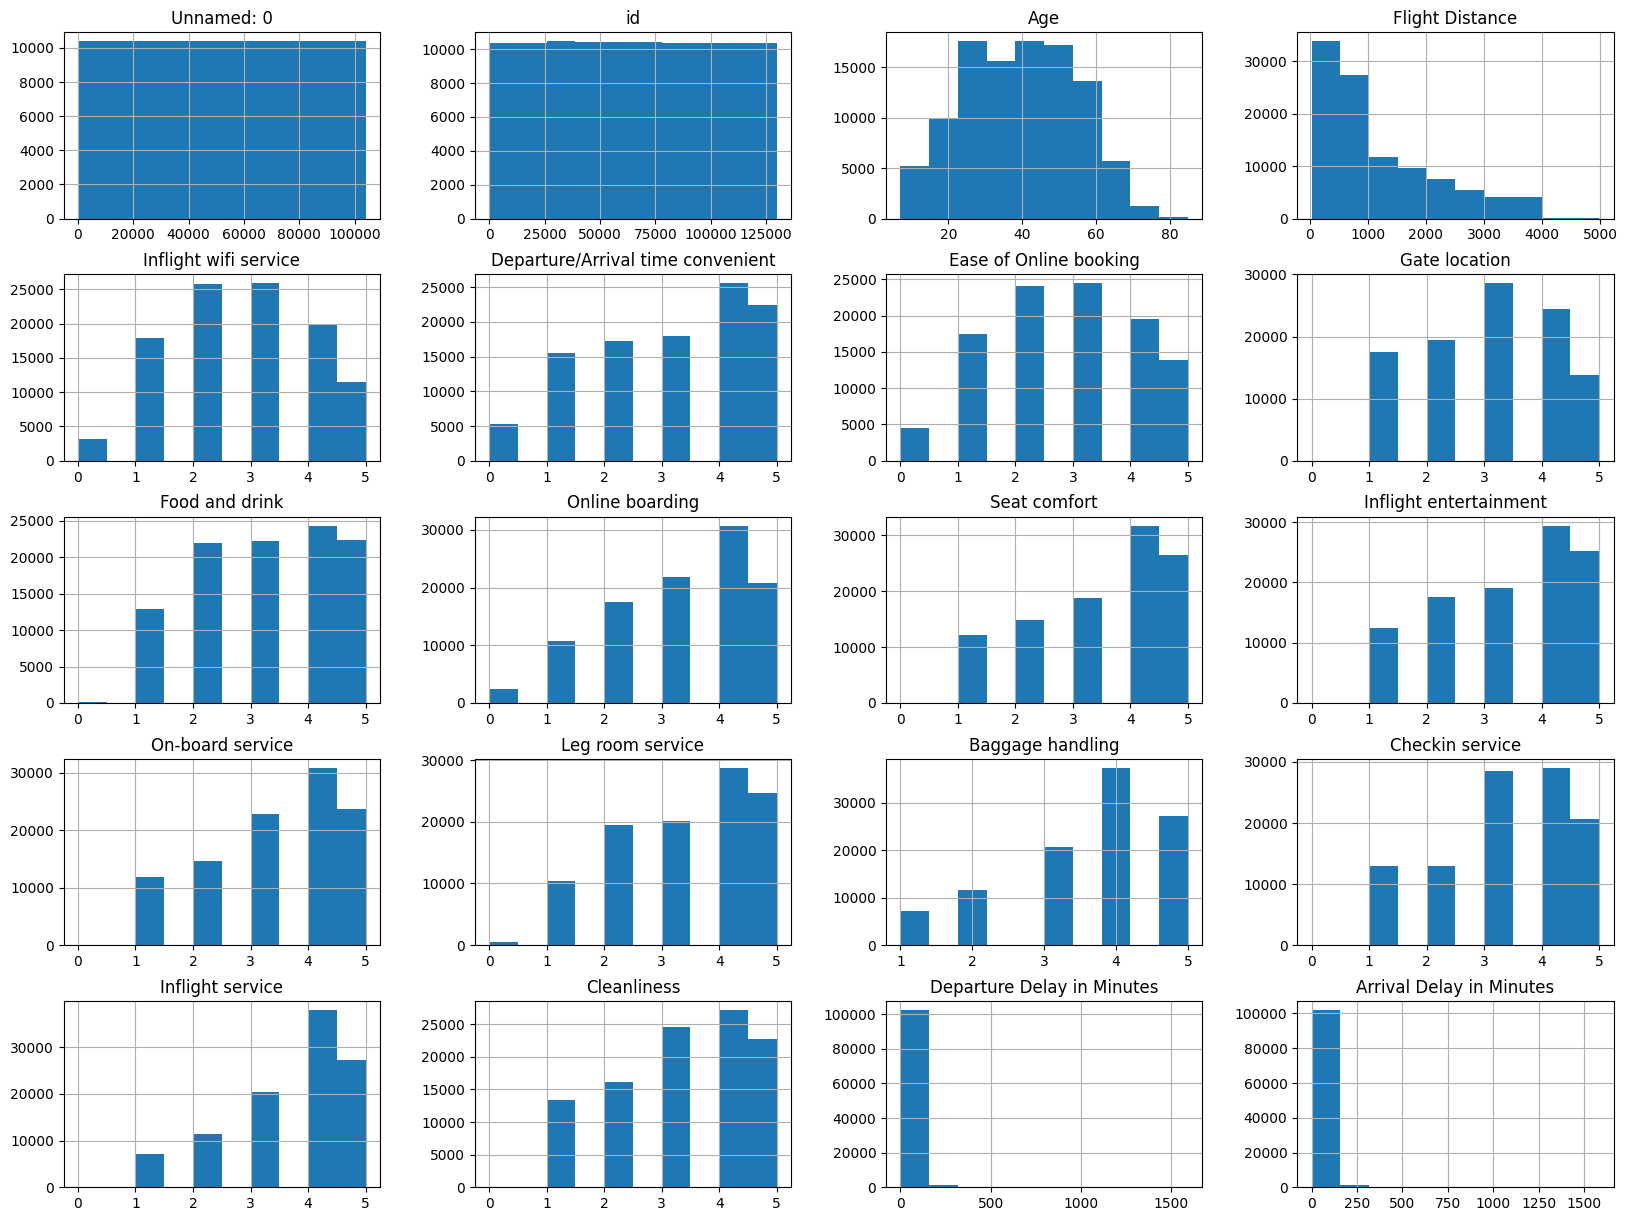

In [ ]:

# Vẽ biểu đồ
Airline.hist(figsize=(20,15))
plt.show()

In [ ]:
Airline.dtypes

,0
Unnamed: 0,int64
id,int64
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64


## 2. Thống kê mô tả

Trước khi tiền xử lý, nhóm sử dụng thống kê mô tả để quan sát nhanh phân bố của các biến số trong tập train.  
Các chỉ số như giá trị trung bình, độ lệch chuẩn, min, max và các phân vị giúp nhóm hiểu được quy mô và mức độ biến động của dữ liệu.

In [ ]:

Airline.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


## 3. Kiểm tra và xử lý giá trị khuyết thiếu

Nhóm kiểm tra số lượng giá trị thiếu trong từng cột để xác định các thuộc tính cần xử lý trước khi huấn luyện mô hình.  
Ở notebook này, biến **`Arrival Delay in Minutes`** được điền bằng giá trị **`-1`** để giữ lại đầy đủ số lượng mẫu và tránh lỗi trong quá trình huấn luyện.

In [ ]:
Airline.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
Airline[Airline.isnull().any(axis=1)]

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
213,213,49608,Female,Loyal Customer,38,Business travel,Eco,109,5,3,...,5,5,2,4,1,1,5,31,NaN,satisfied
1124,1124,73442,Male,Loyal Customer,53,Personal Travel,Eco,1012,3,2,...,4,4,4,4,3,3,4,38,NaN,neutral or dissatisfied
1529,1529,71178,Male,Loyal Customer,39,Business travel,Business,733,2,5,...,2,2,2,2,2,2,3,11,NaN,neutral or dissatisfied
2004,2004,72940,Female,disloyal Customer,26,Business travel,Business,1035,3,3,...,2,3,3,4,5,5,2,41,NaN,neutral or dissatisfied
2108,2108,116374,Female,Loyal Customer,24,Personal Travel,Eco,417,2,1,...,5,1,4,2,1,2,5,1,NaN,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102067,102067,36729,Male,Loyal Customer,49,Personal Travel,Eco Plus,1249,2,5,...,3,4,5,4,3,4,3,230,NaN,neutral or dissatisfied
102384,102384,71241,Male,Loyal Customer,58,Business travel,Eco,733,3,3,...,3,3,1,2,4,2,3,55,NaN,neutral or dissatisfied
102552,102552,27684,Female,disloyal Customer,29,Business travel,Eco,1107,2,1,...,5,4,1,5,5,3,5,0,NaN,neutral or dissatisfied
102960,102960,36787,Male,Loyal Customer,58,Business travel,Eco,1088,4,4,...,5,1,5,5,5,3,5,0,NaN,satisfied


### 3.1. Điền giá trị thiếu cho `Arrival Delay in Minutes`

Việc thay thế giá trị thiếu bằng `-1` là một cách xử lý đơn giản, giúp mô hình vẫn nhận diện được đây là những trường hợp ban đầu bị thiếu dữ liệu.

In [ ]:
Airline["Arrival Delay in Minutes"].fillna(-1, inplace=True)

/tmp/ipykernel_1161/3230107048.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Airline["Arrival Delay in Minutes"].fillna(-1, inplace=True)


### 3.2. Kiểm tra lại sau khi xử lý `NaN`

Sau khi điền giá trị thiếu, nhóm kiểm tra lại cả tập train và test để đảm bảo dữ liệu đã sạch và sẵn sàng cho các bước tiếp theo.

In [ ]:
Airline.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
df["Arrival Delay in Minutes"].fillna(-1, inplace=True)

/tmp/ipykernel_1161/3135565485.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Arrival Delay in Minutes"].fillna(-1, inplace=True)


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


## 4. Trực quan hóa dữ liệu

*   Mục danh sách
*   Mục danh sách



Nhóm sử dụng một số biểu đồ cơ bản để hiểu rõ hơn đặc điểm dữ liệu:

- **Histogram / KDE** cho biến `Age` giúp quan sát phân bố độ tuổi của hành khách
- **Boxplot** hỗ trợ phát hiện outlier ở các biến số
- **Heatmap tương quan** giúp quan sát mối liên hệ giữa các đặc trưng định lượng

Các biểu đồ này giúp nhóm có cái nhìn trực quan trước khi xây dựng mô hình.

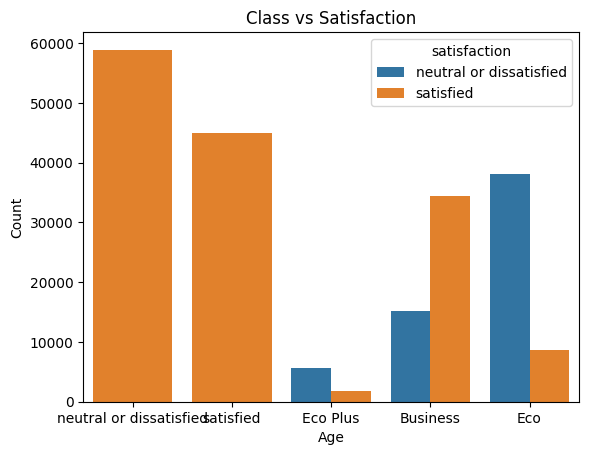

In [ ]:
sns.histplot(Airline["Age"], kde=True)
plt.title("Distribution of Age")
sns.countplot(x="satisfaction", data=Airline)
plt.title("Passenger Satisfaction")
sns.countplot(x="Class", hue="satisfaction", data=Airline)
plt.title("Class vs Satisfaction")
plt.show()


### 4.1. Ma trận tương quan

Heatmap tương quan cho biết cặp biến nào có xu hướng thay đổi cùng nhau hoặc ngược chiều nhau.  
Bước này giúp hiểu dữ liệu tốt hơn và hỗ trợ việc đánh giá mức độ liên hệ giữa các đặc trưng.

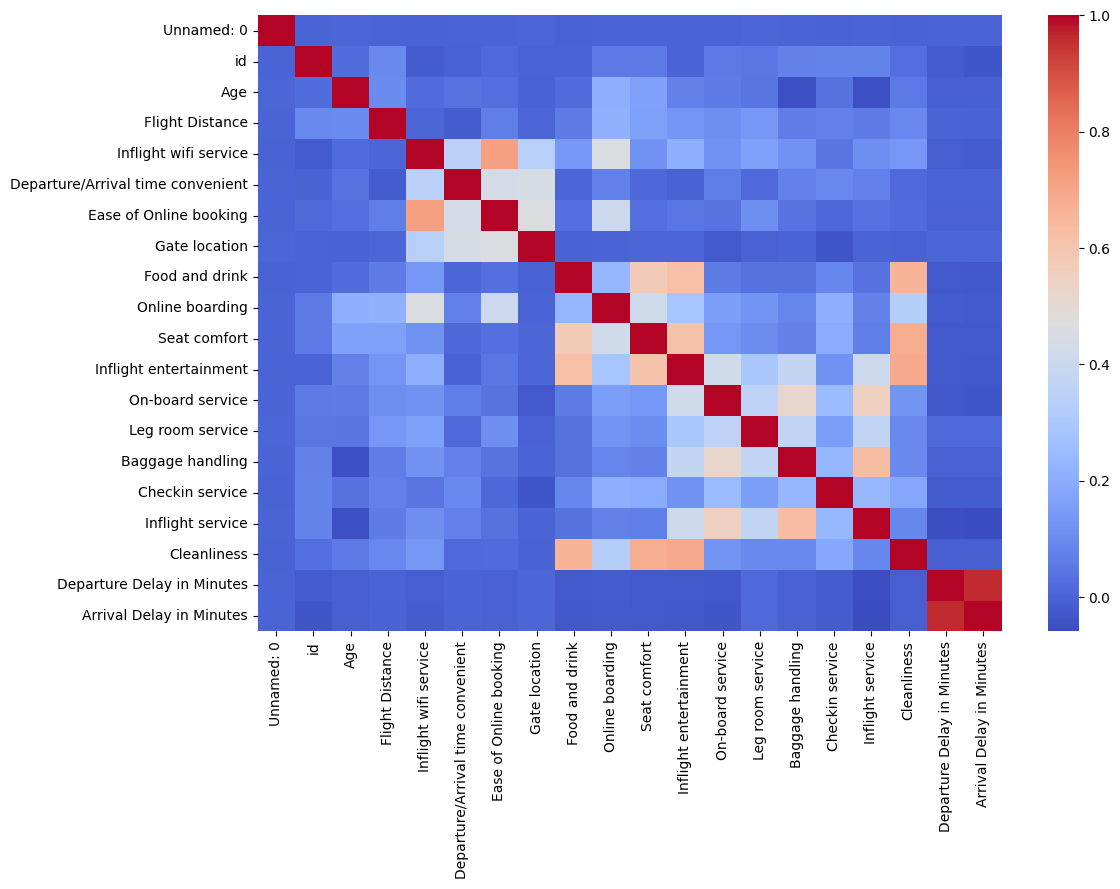

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(Airline.corr(numeric_only=True), cmap="coolwarm")
plt.show()

## 5. Loại bỏ cột không cần thiết và xác định dữ liệu đầu vào

Hai cột `Unnamed: 0` và `id` chỉ mang tính định danh nên được loại bỏ.  
Sau đó, nhóm tách:

- **`X`**: tập đặc trưng đầu vào
- **`y`**: nhãn mục tiêu `satisfaction`

### 5.1. Bộ train

Tập train được dùng để học tham số của mô hình và tạo ra tập validation trong bước chia dữ liệu tiếp theo.

In [ ]:
Airline.drop(["Unnamed: 0","id"], axis=1, inplace=True)

In [ ]:
X = Airline.drop("satisfaction", axis=1)
y= Airline["satisfaction"]

### 5.2. Bộ test

Tập test được giữ riêng để đánh giá khả năng dự đoán của mô hình trên dữ liệu chưa thấy trước.

In [ ]:
df.drop(["Unnamed: 0","id"], axis=1, inplace=True)

In [ ]:
predicted = df.drop("satisfaction", axis=1)
target = df["satisfaction"]

In [ ]:
target

,satisfaction
0,satisfied
1,satisfied
2,neutral or dissatisfied
3,satisfied
4,satisfied
...,...
25971,neutral or dissatisfied
25972,satisfied
25973,neutral or dissatisfied
25974,satisfied


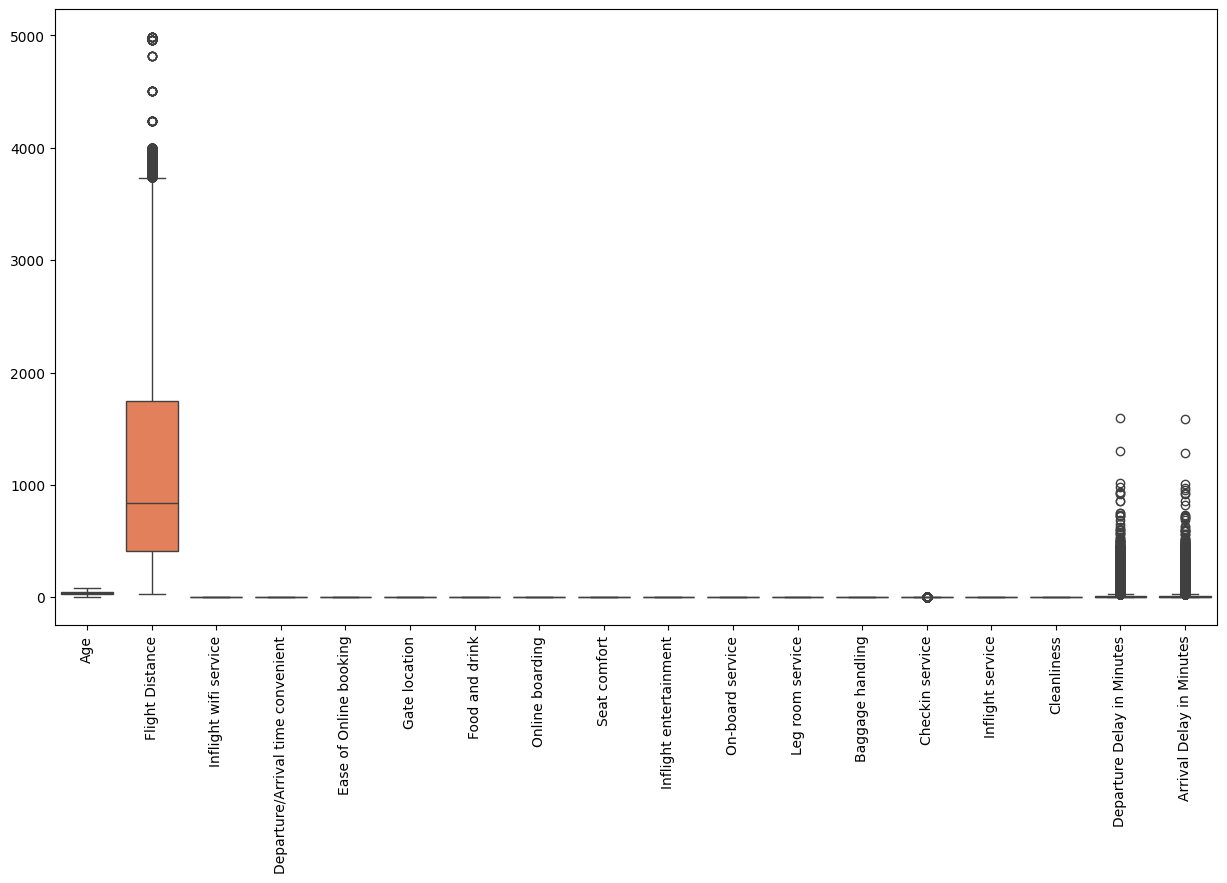

In [ ]:
# Tìm điểm outlier
plt.figure(figsize=(15,8))
sns.boxplot(data=Airline)
plt.xticks(rotation=90)
plt.show()

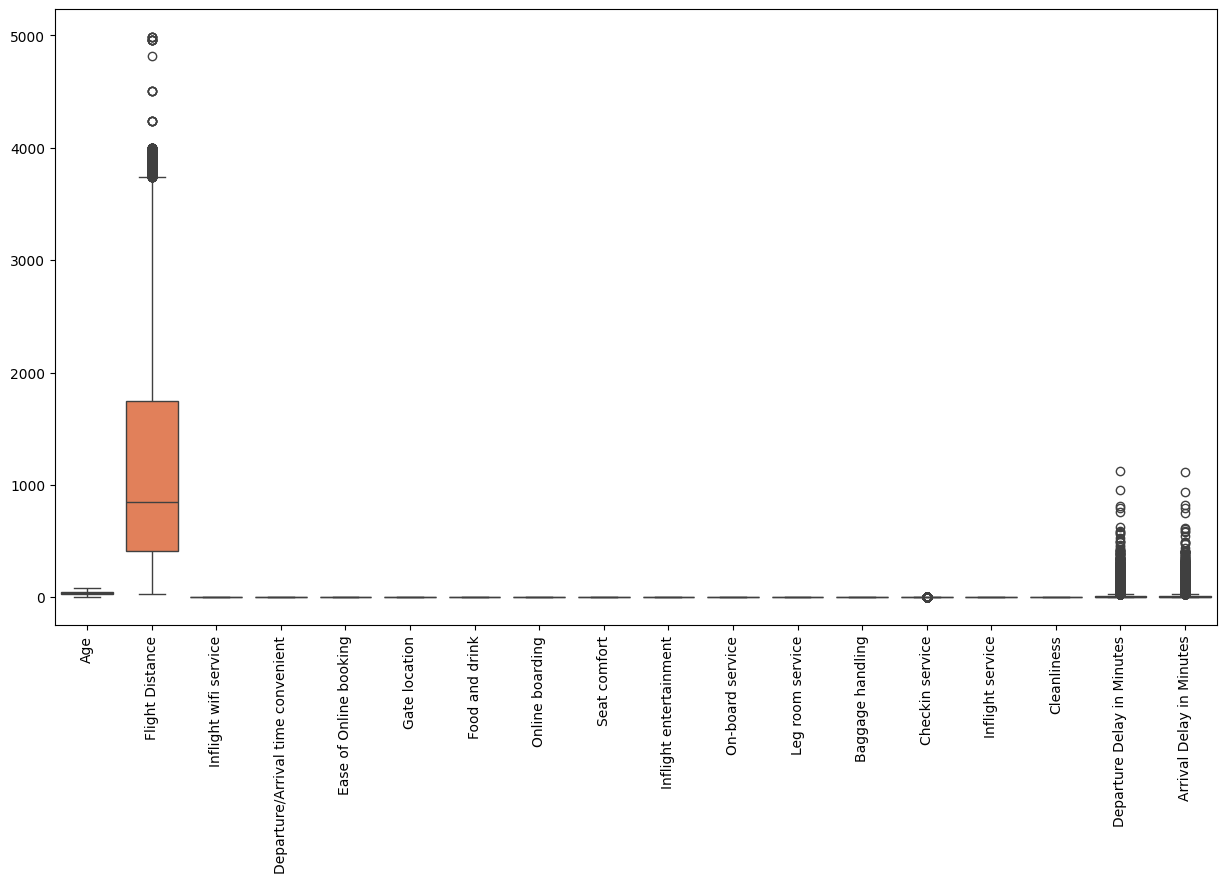

In [ ]:
# Tìm điểm outlier
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

## 6. Xử lý outlier bằng IQR

Ở nhánh thực nghiệm đầu tiên, nhóm xử lý ngoại lệ bằng phương pháp **IQR** cho ba biến:

- `Flight Distance`
- `Departure Delay in Minutes`
- `Arrival Delay in Minutes`

Thay vì xóa bỏ mẫu, nhóm áp dụng **clipping** theo ngưỡng IQR để giảm ảnh hưởng của giá trị quá cực đoan nhưng vẫn giữ nguyên số lượng dữ liệu.

In [ ]:
Q1_A=Airline ['Flight Distance'].quantile(0.25)
Q3_A=Airline ['Flight Distance'].quantile(0.75)
IQR_A=Q3_A-Q1_A
lower_A=Q1_A-1.5*IQR_A
upper_A=Q3_A+1.5*IQR_A
outlier1=Airline[(Airline['Flight Distance']<lower_A)|(Airline['Flight Distance']>upper_A)]

In [ ]:
if lower_A < 0:
  Airline['Flight Distance'] = Airline['Flight Distance'].clip(0, upper_A)
else:
  Airline['Flight Distance'] = Airline['Flight Distance'].clip(lower_A, upper_A)
Airline[(Airline['Flight Distance']<lower_A)|(Airline['Flight Distance']>upper_A)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


In [ ]:
if lower_A < 0:
  df['Flight Distance'] = df['Flight Distance'].clip(0, upper_A)
else:
  df['Flight Distance'] = df['Flight Distance'].clip(lower_A, upper_A)
df[(df['Flight Distance']<lower_A)|(df['Flight Distance']>upper_A)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


In [ ]:
Q1_B=Airline ['Departure Delay in Minutes'].quantile(0.25)
Q3_B=Airline ['Departure Delay in Minutes'].quantile(0.75)
IQR_B=Q3_B-Q1_B
lower_B=Q1_B-1.5*IQR_B
upper_B=Q3_B+1.5*IQR_B
outlier2=Airline[(Airline['Departure Delay in Minutes']<lower_B)|(Airline['Departure Delay in Minutes']>upper_B)]

In [ ]:
if lower_B < 0:
  Airline['Departure Delay in Minutes'] = Airline['Departure Delay in Minutes'].clip(0, upper_B)
else:
  Airline['Departure Delay in Minutes'] = Airline['Departure Delay in Minutes'].clip(lower_B, upper_B)
Airline[(Airline['Departure Delay in Minutes']<lower_B)|(Airline['Departure Delay in Minutes']>upper_B)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


In [ ]:
if lower_B < 0:
  df['Departure Delay in Minutes'] = df['Departure Delay in Minutes'].clip(0, upper_B)
else:
  df['Departure Delay in Minutes'] = df['Departure Delay in Minutes'].clip(lower_B, upper_B)
df[(df['Departure Delay in Minutes']<lower_B)|(df['Departure Delay in Minutes']>upper_B)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


In [ ]:
Q1_C=Airline ['Arrival Delay in Minutes'].quantile(0.25)
Q3_C=Airline ['Arrival Delay in Minutes'].quantile(0.75)
IQR_C=Q3_C-Q1_C
lower_C=Q1_C-1.5*IQR_C
upper_C=Q3_C+1.5*IQR_C
outlier3=Airline[(Airline['Arrival Delay in Minutes']<lower_C)|(Airline['Arrival Delay in Minutes']>upper_C)]

In [ ]:
if lower_C < 0:
  Airline['Arrival Delay in Minutes'] = Airline['Arrival Delay in Minutes'].clip(0, upper_C)
else:
  Airline['Arrival Delay in Minutes'] = Airline['Arrival Delay in Minutes'].clip(lower_C, upper_C)
Airline[(Airline['Arrival Delay in Minutes']<lower_C)|(Airline['Arrival Delay in Minutes']>upper_C)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


In [ ]:
if lower_C < 0:
  df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].clip(0, upper_C)
else:
  df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].clip(lower_C, upper_C)
df[(df['Arrival Delay in Minutes']<lower_C)|(df['Arrival Delay in Minutes']>upper_C)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


### 6.1. Kiểm tra lại sau khi xử lý outlier

Sau khi clipping, nhóm vẽ lại boxplot để kiểm tra mức độ giảm ngoại lệ trước khi đưa dữ liệu vào mô hình.

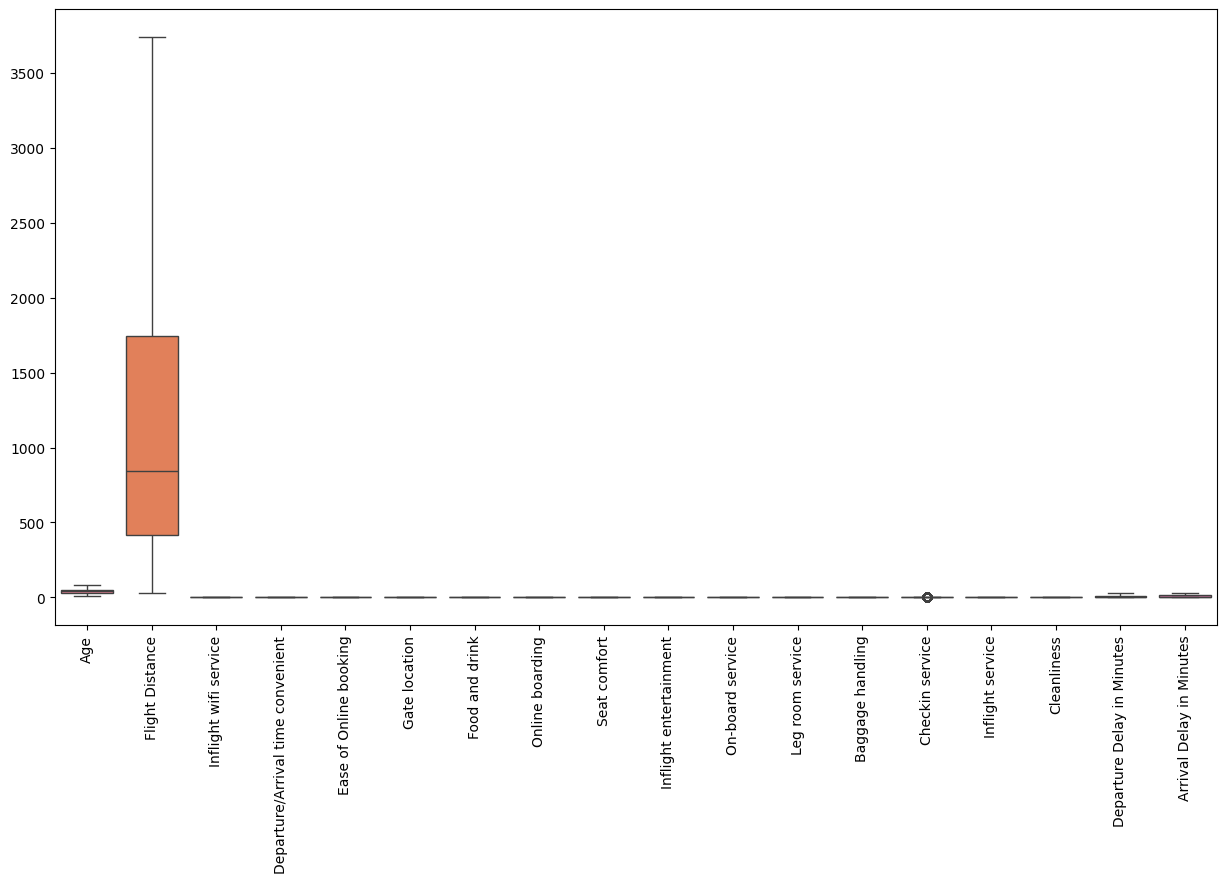

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(Airline)
plt.xticks(rotation=90)
plt.show()

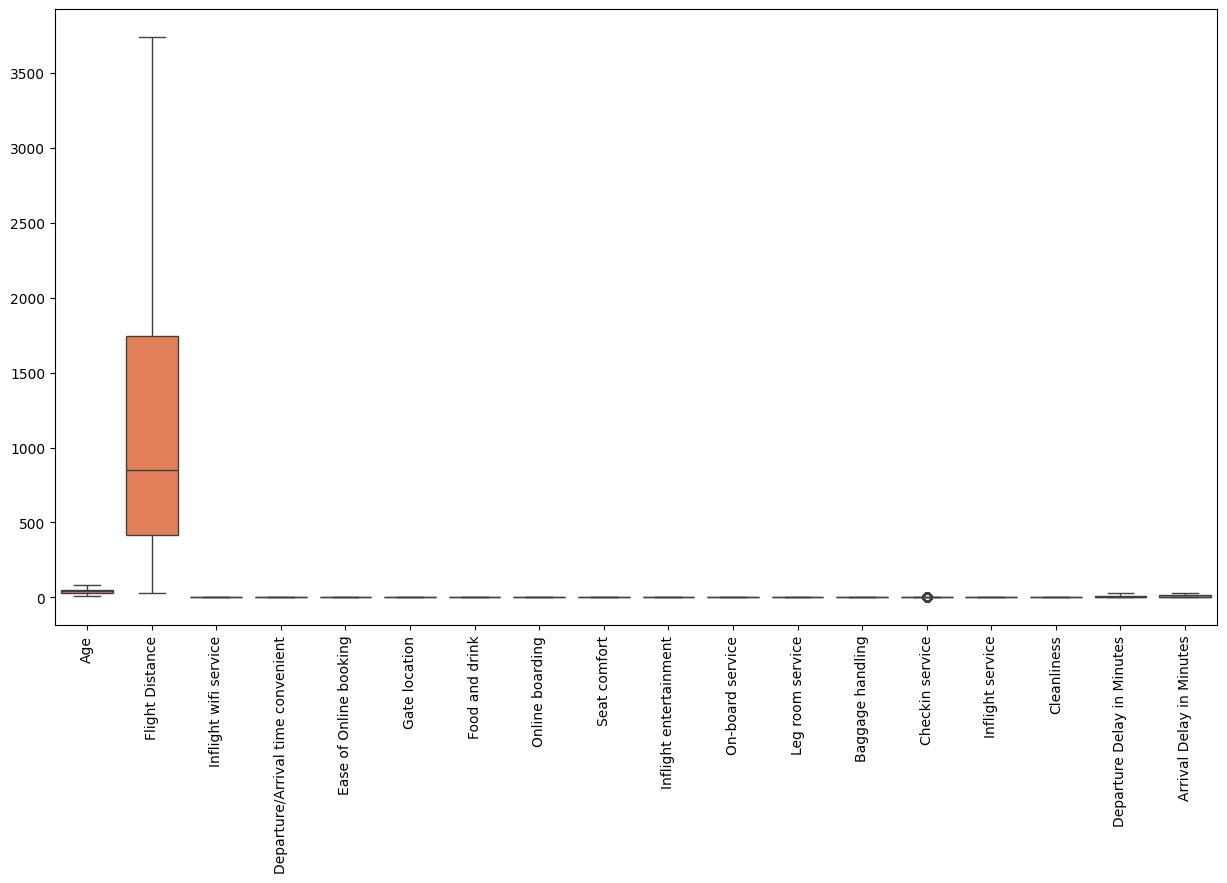

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

## 7. Chia train / validation và mã hóa nhãn

Dữ liệu được chia theo tỷ lệ:

- **80%** cho huấn luyện
- **20%** cho validation

Biến mục tiêu `satisfaction` được mã hóa bằng **LabelEncoder** để chuyển về nhãn nhị phân 0/1, phù hợp với bài toán phân loại.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)

In [ ]:
y_truth= le.transform(target)

In [ ]:
X_train

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,Female,Loyal Customer,59,Personal Travel,Eco,1046,4,5,4,1,...,5,2,2,4,3,5,2,4,12,3.0
36897,Female,disloyal Customer,40,Business travel,Business,752,4,4,4,2,...,5,1,4,2,4,3,5,1,19,29.0
8468,Male,Loyal Customer,65,Personal Travel,Eco,383,2,3,2,1,...,1,1,5,4,5,5,5,1,0,0.0
53490,Female,Loyal Customer,70,Personal Travel,Eco,2239,3,5,3,4,...,4,5,5,3,5,3,5,5,0,0.0
78687,Female,disloyal Customer,25,Business travel,Eco,1358,2,2,2,3,...,1,1,1,2,3,5,2,1,3,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,Male,disloyal Customer,39,Business travel,Eco,637,3,5,3,5,...,3,3,4,3,2,3,2,3,1,0.0
76820,Male,Loyal Customer,17,Personal Travel,Eco,646,3,4,3,1,...,2,3,5,1,2,4,4,3,0,2.0
103694,Male,Loyal Customer,46,Business travel,Eco,1197,1,2,2,2,...,1,4,3,3,3,1,1,1,260,263.0
860,Female,Loyal Customer,37,Business travel,Eco,320,5,5,5,5,...,5,5,1,2,4,1,3,5,0,0.0


In [ ]:
y_train

array([0, 0, 0, ..., 0, 1, 0])

## 8. One-Hot Encoding cho các biến phân loại

Đây là điểm khác biệt chính của **hướng xử lý 2**.  
Các biến phân loại gồm:

- `Gender`
- `Customer Type`
- `Type of Travel`
- `Class`

được mã hóa bằng **One-Hot Encoding**. Đối với biến `Class`, cách biểu diễn này giúp mô hình hiểu đây là các nhóm độc lập, tránh hiểu sai quan hệ thứ tự như khi mã hóa 0, 1, 2.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()

In [ ]:
Mall_airline=X_train[["Gender", "Customer Type", "Type of Travel", "Class"]]
Airline_1hot=encoder.fit_transform(Mall_airline)
Airline_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 332492 stored elements and shape (83123, 9)>

In [ ]:
mall = pd.DataFrame.sparse.from_spmatrix(Airline_1hot,
                                                 columns=encoder.get_feature_names_out(),index=X_train.index)
mall

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
20921,1.0,0,1.0,0,0,1.0,0,1.0,0
36897,1.0,0,0,1.0,1.0,0,1.0,0,0
8468,0,1.0,1.0,0,0,1.0,0,1.0,0
53490,1.0,0,1.0,0,0,1.0,0,1.0,0
78687,1.0,0,0,1.0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...
54886,0,1.0,0,1.0,1.0,0,0,1.0,0
76820,0,1.0,1.0,0,0,1.0,0,1.0,0
103694,0,1.0,1.0,0,1.0,0,0,1.0,0
860,1.0,0,1.0,0,1.0,0,0,1.0,0


In [ ]:
Mall_airline_valid=X_valid[["Gender", "Customer Type", "Type of Travel", "Class"]]
Airline_valid_1hot=encoder.transform(Mall_airline_valid)
Airline_valid_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 83124 stored elements and shape (20781, 9)>

In [ ]:
mall_valid = pd.DataFrame.sparse.from_spmatrix(Airline_valid_1hot,
                                                 columns=encoder.get_feature_names_out(),index=X_valid.index)
mall_valid

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
80638,1.0,0,1.0,0,0,1.0,0,1.0,0
43398,0,1.0,1.0,0,1.0,0,1.0,0,0
32751,1.0,0,1.0,0,0,1.0,0,1.0,0
33571,1.0,0,1.0,0,0,1.0,0,1.0,0
71287,0,1.0,0,1.0,1.0,0,1.0,0,0
...,...,...,...,...,...,...,...,...,...
8158,0,1.0,0,1.0,1.0,0,1.0,0,0
53718,0,1.0,1.0,0,0,1.0,0,1.0,0
33319,0,1.0,1.0,0,0,1.0,0,1.0,0
99162,1.0,0,1.0,0,1.0,0,1.0,0,0


In [ ]:
predict_1hot=predicted[["Gender", "Customer Type", "Type of Travel", "Class"]]
predict_1hot

,Gender,Customer Type,Type of Travel,Class
0,Female,Loyal Customer,Business travel,Eco
1,Female,Loyal Customer,Business travel,Business
2,Male,disloyal Customer,Business travel,Eco
3,Male,Loyal Customer,Business travel,Business
4,Female,Loyal Customer,Business travel,Eco
...,...,...,...,...
25971,Male,disloyal Customer,Business travel,Business
25972,Male,Loyal Customer,Business travel,Business
25973,Female,Loyal Customer,Personal Travel,Eco
25974,Male,Loyal Customer,Business travel,Business


In [ ]:
predict_is_1hot=encoder.transform(predict_1hot)
predict_is_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 103904 stored elements and shape (25976, 9)>

In [ ]:
predict_1hot_df = pd.DataFrame.sparse.from_spmatrix(predict_is_1hot,
                                                 columns=encoder.get_feature_names_out(),index=predicted.index)
predict_1hot_df

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,1.0,0,1.0,0,1.0,0,0,1.0,0
1,1.0,0,1.0,0,1.0,0,1.0,0,0
2,0,1.0,0,1.0,1.0,0,0,1.0,0
3,0,1.0,1.0,0,1.0,0,1.0,0,0
4,1.0,0,1.0,0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...
25971,0,1.0,0,1.0,1.0,0,1.0,0,0
25972,0,1.0,1.0,0,1.0,0,1.0,0,0
25973,1.0,0,1.0,0,0,1.0,0,1.0,0
25974,0,1.0,1.0,0,1.0,0,1.0,0,0


## 9. Chuẩn hóa các biến số

Sau khi tách các biến phân loại để One-Hot, các biến số còn lại được chuẩn hóa bằng **StandardScaler**.  
Bước này giúp các đặc trưng có cùng thang đo, từ đó hỗ trợ Neural Network học ổn định hơn.

In [ ]:
data_scale=X_train.drop(["Gender", "Customer Type", "Type of Travel", "Class"],axis=1)
data_scale

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,59,1046,4,5,4,1,5,4,5,2,2,4,3,5,2,4,12,3.0
36897,40,752,4,4,4,2,1,4,5,1,4,2,4,3,5,1,19,29.0
8468,65,383,2,3,2,1,1,2,1,1,5,4,5,5,5,1,0,0.0
53490,70,2239,3,5,3,4,3,5,4,5,5,3,5,3,5,5,0,0.0
78687,25,1358,2,2,2,3,1,2,1,1,1,2,3,5,2,1,3,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,39,637,3,5,3,5,3,3,3,3,4,3,2,3,2,3,1,0.0
76820,17,646,3,4,3,1,3,3,2,3,5,1,2,4,4,3,0,2.0
103694,46,1197,1,2,2,2,1,1,1,4,3,3,3,1,1,1,260,263.0
860,37,320,5,5,5,5,5,5,5,5,1,2,4,1,3,5,0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
num_scale = std_scaler.fit_transform(data_scale)
num_scale

array([[ 1.29986657, -0.14310337,  0.95637727, ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 0.04355119, -0.43800734,  0.95637727, ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 1.69659774, -0.80814191, -0.54993143, ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.44028236,  0.00836091, -1.30308577, ..., -1.74028074,
         6.36841631,  6.36599827],
       [-0.15481439, -0.87133562,  1.70953161, ...,  1.31011424,
        -0.38581206, -0.38942783],
       [-1.67561721, -0.8402403 ,  0.95637727, ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
scaled_k=pd.DataFrame(num_scale,
                      columns=std_scaler.get_feature_names_out(),index=X_train.index)
scaled_k

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,1.299867,-0.143103,0.956377,1.271553,0.887405,-1.549472,1.354730,0.558180,1.185329,-1.017279,-1.074922,0.491774,-0.532883,1.339119,-1.395033,0.547515,-0.074078,-0.312370
36897,0.043551,-0.438007,0.956377,0.616850,0.887405,-0.766108,-1.658287,0.558180,1.185329,-1.768222,0.478625,-1.029881,0.313521,-0.241843,1.157994,-1.740281,0.107766,0.355467
8468,1.696598,-0.808142,-0.549931,-0.037854,-0.542403,-1.549472,-1.658287,-0.923888,-1.846677,-1.768222,1.255399,0.491774,1.159924,1.339119,1.157994,-1.740281,-0.385812,-0.389428
53490,2.027207,1.053565,0.203223,1.271553,0.172501,0.800620,-0.151778,1.299214,0.427327,1.235552,1.255399,-0.269054,1.159924,-0.241843,1.157994,1.310114,-0.385812,-0.389428
78687,-0.948277,0.169856,-0.549931,-0.692557,-0.542403,0.017256,-1.658287,-0.923888,-1.846677,-1.768222,-1.851695,-1.029881,-0.532883,1.339119,-1.395033,-1.740281,-0.307879,-0.004137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,-0.022571,-0.553361,0.203223,1.271553,0.172501,1.583984,-0.151778,-0.182854,-0.330674,-0.266335,0.478625,-0.269054,-1.379287,-0.241843,-1.395033,-0.215083,-0.359834,-0.389428
76820,-1.477252,-0.544333,0.203223,0.616850,0.172501,-1.549472,-0.151778,-0.182854,-1.088676,-0.266335,1.255399,-1.790709,-1.379287,0.548638,0.306985,-0.215083,-0.385812,-0.338056
103694,0.440282,0.008361,-1.303086,-0.692557,-0.542403,-0.766108,-1.658287,-1.664922,-1.846677,0.484609,-0.298148,-0.269054,-0.532883,-1.822805,-2.246042,-1.740281,6.368416,6.365998
860,-0.154814,-0.871336,1.709532,1.271553,1.602309,1.583984,1.354730,1.299214,1.185329,1.235552,-1.851695,-1.029881,0.313521,-1.822805,-0.544024,1.310114,-0.385812,-0.389428


In [ ]:
valid_scale=X_valid.drop(["Gender", "Customer Type", "Type of Travel", "Class"],axis=1)
valid_scale

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
80638,26,861,2,4,2,5,5,2,5,5,5,4,4,3,5,5,0,0.0
43398,22,393,3,5,5,5,3,3,3,3,1,1,3,2,3,3,0,16.0
32751,59,196,1,3,1,3,2,3,3,4,4,1,4,3,4,4,37,34.0
33571,32,1020,2,3,2,4,4,2,4,4,3,2,4,1,4,4,27,4.0
71287,35,1117,2,2,2,1,2,2,5,2,2,2,3,2,2,2,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,42,236,1,1,1,3,1,1,1,1,2,3,4,2,4,1,0,0.0
53718,14,558,2,4,2,2,5,2,5,5,4,4,5,5,4,5,0,0.0
33319,9,1005,2,5,2,3,5,2,5,5,4,4,2,3,5,5,1,0.0
99162,45,3234,3,3,3,3,5,5,5,4,4,4,4,3,4,3,0,19.0


In [ ]:
num_scale_valid = std_scaler.transform(valid_scale)
num_scale_valid

array([[-0.88215487, -0.32867219, -0.54993143, ...,  1.31011424,
        -0.38581206, -0.38942783],
       [-1.14664232, -0.79811117,  0.20322292, ..., -0.21508325,
        -0.38581206,  0.02154866],
       [ 1.29986657, -0.99571689, -1.30308577, ...,  0.54751549,
         0.5753666 ,  0.48389722],
       ...,
       [-2.00622652, -0.18422943, -0.54993143, ...,  1.31011424,
        -0.35983426, -0.38942783],
       [ 0.3741605 ,  2.05162413,  0.20322292, ..., -0.21508325,
        -0.38581206,  0.09860676],
       [-0.55154556, -1.10605511,  0.95637727, ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
scaled_valid=pd.DataFrame(num_scale_valid,
                      columns=std_scaler.get_feature_names_out(),index=X_valid.index)
scaled_valid

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
80638,-0.882155,-0.328672,-0.549931,0.616850,-0.542403,1.583984,1.354730,-0.923888,1.185329,1.235552,1.255399,0.491774,0.313521,-0.241843,1.157994,1.310114,-0.385812,-0.389428
43398,-1.146642,-0.798111,0.203223,1.271553,1.602309,1.583984,-0.151778,-0.182854,-0.330674,-0.266335,-1.851695,-1.790709,-0.532883,-1.032324,-0.544024,-0.215083,-0.385812,0.021549
32751,1.299867,-0.995717,-1.303086,-0.037854,-1.257307,0.017256,-0.905032,-0.182854,-0.330674,0.484609,0.478625,-1.790709,0.313521,-0.241843,0.306985,0.547515,0.575367,0.483897
33571,-0.485424,-0.169183,-0.549931,-0.037854,-0.542403,0.800620,0.601476,-0.923888,0.427327,0.484609,-0.298148,-1.029881,0.313521,-1.822805,0.306985,0.547515,0.315589,-0.286684
71287,-0.287058,-0.071885,-0.549931,-0.692557,-0.542403,-1.549472,-0.905032,-0.923888,1.185329,-1.017279,-1.074922,-1.029881,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,0.175795,-0.955594,-1.303086,-1.347261,-1.257307,0.017256,-1.658287,-1.664922,-1.846677,-1.768222,-1.074922,-0.269054,0.313521,-1.032324,0.306985,-1.740281,-0.385812,-0.389428
53718,-1.675617,-0.632604,-0.549931,0.616850,-0.542403,-0.766108,1.354730,-0.923888,1.185329,1.235552,0.478625,0.491774,1.159924,1.339119,0.306985,1.310114,-0.385812,-0.389428
33319,-2.006227,-0.184229,-0.549931,1.271553,-0.542403,0.017256,1.354730,-0.923888,1.185329,1.235552,0.478625,0.491774,-1.379287,-0.241843,1.157994,1.310114,-0.359834,-0.389428
99162,0.374161,2.051624,0.203223,-0.037854,0.172501,0.017256,1.354730,1.299214,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,-0.215083,-0.385812,0.098607


In [ ]:
scaled_predict=predicted.drop(["Gender", "Customer Type", "Type of Travel", "Class"],axis=1)
scaled_predict

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,52,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0
1,36,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0
2,20,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0
3,44,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0
4,49,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,34,526,3,3,3,1,4,3,4,4,3,2,4,4,5,4,0,0.0
25972,23,646,4,4,4,4,4,4,4,4,4,5,5,5,5,4,0,0.0
25973,17,828,2,5,1,5,2,1,2,2,4,3,4,5,4,2,0,0.0
25974,14,1127,3,3,3,3,4,4,4,4,3,2,5,4,5,4,0,0.0


In [ ]:
num_pre1 = std_scaler.transform(scaled_predict)
num_pre1

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  1.31011424,
         0.91307801,  0.74075753],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.31011424,
        -0.38581206, -0.38942783],
       [-1.27888604, -0.99972919, -0.54993143, ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ..., -0.97768199,
        -0.38581206, -0.38942783],
       [-1.67561721, -0.06185432,  0.20322292, ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 0.17579492, -0.9275078 , -0.54993143, ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
scaled_predict_df=pd.DataFrame(num_pre1,
                      columns=std_scaler.get_feature_names_out(),index=predicted.index)
scaled_predict_df

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0.837014,-1.031828,1.709532,0.616850,0.172501,0.800620,-0.151778,0.558180,-0.330674,1.235552,1.255399,1.252602,1.159924,-1.032324,1.157994,1.310114,0.913078,0.740758
1,-0.220936,1.679483,-1.303086,-1.347261,0.172501,-1.549472,1.354730,0.558180,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,1.310114,-0.385812,-0.389428
2,-1.278886,-0.999729,-0.549931,-2.001964,-0.542403,0.800620,-0.905032,-0.923888,-1.088676,-1.017279,0.478625,-1.790709,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
3,0.308039,2.195064,-2.056240,-2.001964,-1.972211,-0.766108,-0.151778,0.558180,0.427327,-1.768222,-1.851695,-1.790709,-2.225690,-0.241843,-2.246042,0.547515,-0.385812,-0.235312
4,0.638648,-0.006685,-0.549931,-0.037854,0.887405,0.017256,0.601476,-1.664922,-1.088676,-1.017279,-1.074922,-1.029881,-1.379287,0.548638,-1.395033,0.547515,-0.385812,0.124293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,-0.353180,-0.664702,0.203223,-0.037854,0.172501,-1.549472,0.601476,-0.182854,0.427327,0.484609,-0.298148,-1.029881,0.313521,0.548638,1.157994,0.547515,-0.385812,-0.389428
25972,-1.080520,-0.544333,0.956377,0.616850,0.887405,0.800620,0.601476,0.558180,0.427327,0.484609,0.478625,1.252602,1.159924,1.339119,1.157994,0.547515,-0.385812,-0.389428
25973,-1.477252,-0.361774,-0.549931,1.271553,-1.257307,1.583984,-0.905032,-1.664922,-1.088676,-1.017279,0.478625,-0.269054,0.313521,1.339119,0.306985,-0.977682,-0.385812,-0.389428
25974,-1.675617,-0.061854,0.203223,-0.037854,0.172501,0.017256,0.601476,0.558180,0.427327,0.484609,-0.298148,-1.029881,1.159924,0.548638,1.157994,0.547515,-0.385812,-0.389428


In [ ]:
final_df=pd.concat([mall,scaled_k],axis=1,join='inner')
final_df

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Age,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,1.0,0,1.0,0,0,1.0,0,1.0,0,1.299867,...,1.185329,-1.017279,-1.074922,0.491774,-0.532883,1.339119,-1.395033,0.547515,-0.074078,-0.312370
36897,1.0,0,0,1.0,1.0,0,1.0,0,0,0.043551,...,1.185329,-1.768222,0.478625,-1.029881,0.313521,-0.241843,1.157994,-1.740281,0.107766,0.355467
8468,0,1.0,1.0,0,0,1.0,0,1.0,0,1.696598,...,-1.846677,-1.768222,1.255399,0.491774,1.159924,1.339119,1.157994,-1.740281,-0.385812,-0.389428
53490,1.0,0,1.0,0,0,1.0,0,1.0,0,2.027207,...,0.427327,1.235552,1.255399,-0.269054,1.159924,-0.241843,1.157994,1.310114,-0.385812,-0.389428
78687,1.0,0,0,1.0,1.0,0,0,1.0,0,-0.948277,...,-1.846677,-1.768222,-1.851695,-1.029881,-0.532883,1.339119,-1.395033,-1.740281,-0.307879,-0.004137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0,1.0,0,1.0,1.0,0,0,1.0,0,-0.022571,...,-0.330674,-0.266335,0.478625,-0.269054,-1.379287,-0.241843,-1.395033,-0.215083,-0.359834,-0.389428
76820,0,1.0,1.0,0,0,1.0,0,1.0,0,-1.477252,...,-1.088676,-0.266335,1.255399,-1.790709,-1.379287,0.548638,0.306985,-0.215083,-0.385812,-0.338056
103694,0,1.0,1.0,0,1.0,0,0,1.0,0,0.440282,...,-1.846677,0.484609,-0.298148,-0.269054,-0.532883,-1.822805,-2.246042,-1.740281,6.368416,6.365998
860,1.0,0,1.0,0,1.0,0,0,1.0,0,-0.154814,...,1.185329,1.235552,-1.851695,-1.029881,0.313521,-1.822805,-0.544024,1.310114,-0.385812,-0.389428


In [ ]:
valid_df=pd.concat([mall_valid,scaled_valid],axis=1,join='inner')
valid_df

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Age,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
80638,1.0,0,1.0,0,0,1.0,0,1.0,0,-0.882155,...,1.185329,1.235552,1.255399,0.491774,0.313521,-0.241843,1.157994,1.310114,-0.385812,-0.389428
43398,0,1.0,1.0,0,1.0,0,1.0,0,0,-1.146642,...,-0.330674,-0.266335,-1.851695,-1.790709,-0.532883,-1.032324,-0.544024,-0.215083,-0.385812,0.021549
32751,1.0,0,1.0,0,0,1.0,0,1.0,0,1.299867,...,-0.330674,0.484609,0.478625,-1.790709,0.313521,-0.241843,0.306985,0.547515,0.575367,0.483897
33571,1.0,0,1.0,0,0,1.0,0,1.0,0,-0.485424,...,0.427327,0.484609,-0.298148,-1.029881,0.313521,-1.822805,0.306985,0.547515,0.315589,-0.286684
71287,0,1.0,0,1.0,1.0,0,1.0,0,0,-0.287058,...,1.185329,-1.017279,-1.074922,-1.029881,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,0,1.0,0,1.0,1.0,0,1.0,0,0,0.175795,...,-1.846677,-1.768222,-1.074922,-0.269054,0.313521,-1.032324,0.306985,-1.740281,-0.385812,-0.389428
53718,0,1.0,1.0,0,0,1.0,0,1.0,0,-1.675617,...,1.185329,1.235552,0.478625,0.491774,1.159924,1.339119,0.306985,1.310114,-0.385812,-0.389428
33319,0,1.0,1.0,0,0,1.0,0,1.0,0,-2.006227,...,1.185329,1.235552,0.478625,0.491774,-1.379287,-0.241843,1.157994,1.310114,-0.359834,-0.389428
99162,1.0,0,1.0,0,1.0,0,1.0,0,0,0.374161,...,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,-0.215083,-0.385812,0.098607


In [ ]:
predict_df=pd.concat([scaled_predict_df,predict_1hot_df],axis=1,join='inner')
predict_df

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0.837014,-1.031828,1.709532,0.616850,0.172501,0.800620,-0.151778,0.558180,-0.330674,1.235552,...,0.740758,1.0,0,1.0,0,1.0,0,0,1.0,0
1,-0.220936,1.679483,-1.303086,-1.347261,0.172501,-1.549472,1.354730,0.558180,1.185329,0.484609,...,-0.389428,1.0,0,1.0,0,1.0,0,1.0,0,0
2,-1.278886,-0.999729,-0.549931,-2.001964,-0.542403,0.800620,-0.905032,-0.923888,-1.088676,-1.017279,...,-0.389428,0,1.0,0,1.0,1.0,0,0,1.0,0
3,0.308039,2.195064,-2.056240,-2.001964,-1.972211,-0.766108,-0.151778,0.558180,0.427327,-1.768222,...,-0.235312,0,1.0,1.0,0,1.0,0,1.0,0,0
4,0.638648,-0.006685,-0.549931,-0.037854,0.887405,0.017256,0.601476,-1.664922,-1.088676,-1.017279,...,0.124293,1.0,0,1.0,0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,-0.353180,-0.664702,0.203223,-0.037854,0.172501,-1.549472,0.601476,-0.182854,0.427327,0.484609,...,-0.389428,0,1.0,0,1.0,1.0,0,1.0,0,0
25972,-1.080520,-0.544333,0.956377,0.616850,0.887405,0.800620,0.601476,0.558180,0.427327,0.484609,...,-0.389428,0,1.0,1.0,0,1.0,0,1.0,0,0
25973,-1.477252,-0.361774,-0.549931,1.271553,-1.257307,1.583984,-0.905032,-1.664922,-1.088676,-1.017279,...,-0.389428,1.0,0,1.0,0,0,1.0,0,1.0,0
25974,-1.675617,-0.061854,0.203223,-0.037854,0.172501,0.017256,0.601476,0.558180,0.427327,0.484609,...,-0.389428,0,1.0,1.0,0,1.0,0,1.0,0,0


In [ ]:
final_df

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Age,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,1.0,0,1.0,0,0,1.0,0,1.0,0,1.299867,...,1.185329,-1.017279,-1.074922,0.491774,-0.532883,1.339119,-1.395033,0.547515,-0.074078,-0.312370
36897,1.0,0,0,1.0,1.0,0,1.0,0,0,0.043551,...,1.185329,-1.768222,0.478625,-1.029881,0.313521,-0.241843,1.157994,-1.740281,0.107766,0.355467
8468,0,1.0,1.0,0,0,1.0,0,1.0,0,1.696598,...,-1.846677,-1.768222,1.255399,0.491774,1.159924,1.339119,1.157994,-1.740281,-0.385812,-0.389428
53490,1.0,0,1.0,0,0,1.0,0,1.0,0,2.027207,...,0.427327,1.235552,1.255399,-0.269054,1.159924,-0.241843,1.157994,1.310114,-0.385812,-0.389428
78687,1.0,0,0,1.0,1.0,0,0,1.0,0,-0.948277,...,-1.846677,-1.768222,-1.851695,-1.029881,-0.532883,1.339119,-1.395033,-1.740281,-0.307879,-0.004137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0,1.0,0,1.0,1.0,0,0,1.0,0,-0.022571,...,-0.330674,-0.266335,0.478625,-0.269054,-1.379287,-0.241843,-1.395033,-0.215083,-0.359834,-0.389428
76820,0,1.0,1.0,0,0,1.0,0,1.0,0,-1.477252,...,-1.088676,-0.266335,1.255399,-1.790709,-1.379287,0.548638,0.306985,-0.215083,-0.385812,-0.338056
103694,0,1.0,1.0,0,1.0,0,0,1.0,0,0.440282,...,-1.846677,0.484609,-0.298148,-0.269054,-0.532883,-1.822805,-2.246042,-1.740281,6.368416,6.365998
860,1.0,0,1.0,0,1.0,0,0,1.0,0,-0.154814,...,1.185329,1.235552,-1.851695,-1.029881,0.313521,-1.822805,-0.544024,1.310114,-0.385812,-0.389428


In [ ]:
predict_df

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0.837014,-1.031828,1.709532,0.616850,0.172501,0.800620,-0.151778,0.558180,-0.330674,1.235552,...,0.740758,1.0,0,1.0,0,1.0,0,0,1.0,0
1,-0.220936,1.679483,-1.303086,-1.347261,0.172501,-1.549472,1.354730,0.558180,1.185329,0.484609,...,-0.389428,1.0,0,1.0,0,1.0,0,1.0,0,0
2,-1.278886,-0.999729,-0.549931,-2.001964,-0.542403,0.800620,-0.905032,-0.923888,-1.088676,-1.017279,...,-0.389428,0,1.0,0,1.0,1.0,0,0,1.0,0
3,0.308039,2.195064,-2.056240,-2.001964,-1.972211,-0.766108,-0.151778,0.558180,0.427327,-1.768222,...,-0.235312,0,1.0,1.0,0,1.0,0,1.0,0,0
4,0.638648,-0.006685,-0.549931,-0.037854,0.887405,0.017256,0.601476,-1.664922,-1.088676,-1.017279,...,0.124293,1.0,0,1.0,0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,-0.353180,-0.664702,0.203223,-0.037854,0.172501,-1.549472,0.601476,-0.182854,0.427327,0.484609,...,-0.389428,0,1.0,0,1.0,1.0,0,1.0,0,0
25972,-1.080520,-0.544333,0.956377,0.616850,0.887405,0.800620,0.601476,0.558180,0.427327,0.484609,...,-0.389428,0,1.0,1.0,0,1.0,0,1.0,0,0
25973,-1.477252,-0.361774,-0.549931,1.271553,-1.257307,1.583984,-0.905032,-1.664922,-1.088676,-1.017279,...,-0.389428,1.0,0,1.0,0,0,1.0,0,1.0,0
25974,-1.675617,-0.061854,0.203223,-0.037854,0.172501,0.017256,0.601476,0.558180,0.427327,0.484609,...,-0.389428,0,1.0,1.0,0,1.0,0,1.0,0,0


In [ ]:
final_df.to_csv('cleaned_train_data_with_outliers_handled.csv', index=False)
print('Đã xuất final_df sang cleaned_train_data_with_outliers_handled.csv')

Đã xuất final_df sang cleaned_train_data_with_outliers_handled.csv


In [ ]:
predict_df.to_csv('cleaned_test_data_with_outliers_handled.csv', index=False)
print('Đã xuất predict_df sang cleaned_test_data_with_outliers_handled.csv')

Đã xuất predict_df sang cleaned_test_data_with_outliers_handled.csv


## 10. Huấn luyện mô hình Neural Network trên dữ liệu đã xử lý outlier

Ở nhánh này, nhóm thử nhiều mô hình **MLP** với kiến trúc `Dense` nhiều lớp để dự đoán nhãn `satisfaction`.  
Các mô hình chủ yếu khác nhau ở:

- **optimizer**: `SGD`, `Adam`, `Adagrad`, `Adadelta`, `Adamax`
- **activation ở lớp đầu ra**: `sigmoid` hoặc `relu`

Biểu đồ `accuracy` và `loss` theo epoch giúp theo dõi quá trình học và quan sát dấu hiệu overfitting.

In [ ]:
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
# Xây dựng model Sequential
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(27, activation="relu"))
model.add(tf.keras.layers.Dense(20, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="relu"))
model.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
lr=0.1
my_opt = tf.keras.optimizers.SGD(learning_rate=lr)
model.compile(
    loss="binary_crossentropy",
    optimizer=my_opt,
    metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
x_train_model=final_df.to_numpy().astype('float64')
x_train_model

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
x_valid_model=valid_df.to_numpy().astype('float64')
x_valid_model

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ..., -0.21508325,
        -0.38581206,  0.02154866],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
         0.5753666 ,  0.48389722],
       ...,
       [ 0.        ,  1.        ,  1.        , ...,  1.31011424,
        -0.35983426, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -0.21508325,
        -0.38581206,  0.09860676],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history = model.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4754 - loss: 8.1591 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4326 - loss: 9.0461 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4326 - loss: 9.0461 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.4326 - loss: 9.0461 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4326 - loss: 9.0461 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - accuracy: 0.4326 - loss: 9.0461 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.4326 - loss: 9.0461 - val_accuracy: 0.4364 - val_loss: 8.9858
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.4326 - loss: 9.046

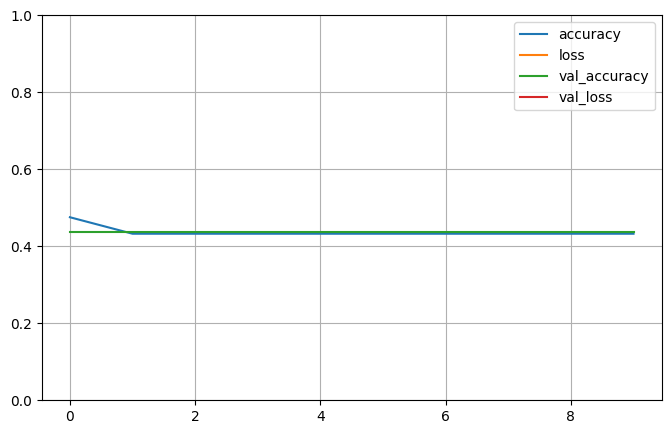

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
result=model.predict(predict_df)
result

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[1.9093926],
       [3.5269475],
       [7.2131286],
       ...,
       [1.5100937],
       [2.7025032],
       [8.245973 ]], dtype=float32)

In [ ]:
pre=result.round(0).astype('int')
pre

array([[2],
       [4],
       [7],
       ...,
       [2],
       [3],
       [8]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre)

0.0014243917462272867

In [ ]:
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Dense(27, activation="relu"))
#model1.add(tf.keras.layers.Dense(20, activation="relu"))
model1.add(tf.keras.layers.Dense(10, activation="relu"))
model1.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model1.compile(
    loss="binary_crossentropy",
    optimizer='Adam',
    metrics=["accuracy"])

In [ ]:
history1 = model1.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9115 - loss: 0.2210 - val_accuracy: 0.9359 - val_loss: 0.1609
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9375 - loss: 0.1515 - val_accuracy: 0.9421 - val_loss: 0.1383
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9437 - loss: 0.1344 - val_accuracy: 0.9471 - val_loss: 0.1259
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9475 - loss: 0.1251 - val_accuracy: 0.9491 - val_loss: 0.1190
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9500 - loss: 0.1193 - val_accuracy: 0.9503 - val_loss: 0.1152
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9515 - loss: 0.1152 - val_accuracy: 0.9508 - val_loss: 0.1131
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9525 - loss: 0.1119 - val_accuracy: 0.9521 - val_loss: 0.1100
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9534 - loss: 0.1091 

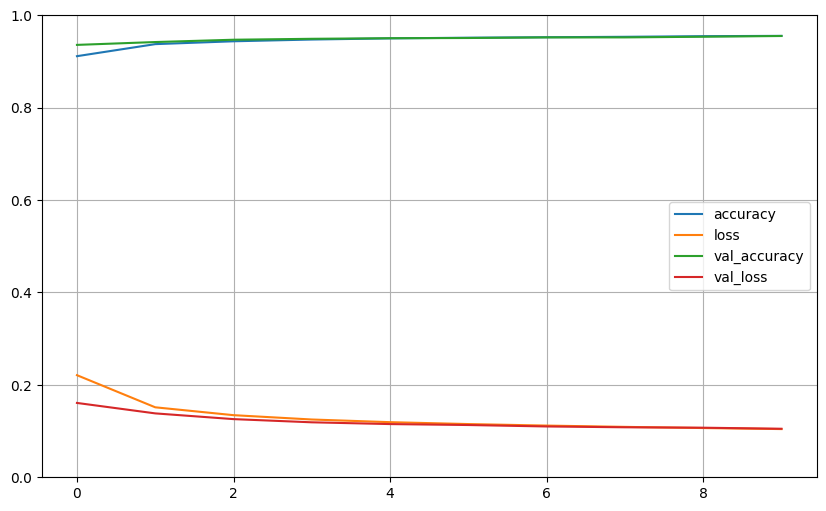

In [ ]:
pd.DataFrame(history1.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict1=predict_df.to_numpy().astype('float64')
data_predict1

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
len(data_predict1)

25976

In [ ]:
result1=model1.predict(data_predict1)
result1

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.85713786],
       [1.        ],
       [1.        ],
       ...,
       [1.        ],
       [0.9999992 ],
       [1.        ]], dtype=float32)

In [ ]:
pre1=result1.round(0).astype('int')
pre1

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]])

In [ ]:
target_y1=le.transform(y)
target_y1

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre1)

0.381967970434247

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_truth, pre1)

0.4608047289581514

In [ ]:
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Dense(27, activation="relu"))
model2.add(tf.keras.layers.Dense(20, activation="relu"))
model2.add(tf.keras.layers.Dense(10, activation="relu"))
model2.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model2.compile(
    loss="binary_crossentropy",
    optimizer='adagrad',
    metrics=["accuracy"])

In [ ]:
history2 = model2.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7568 - loss: 0.5269 - val_accuracy: 0.8280 - val_loss: 0.4342
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8382 - loss: 0.4041 - val_accuracy: 0.8448 - val_loss: 0.3811
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8514 - loss: 0.3701 - val_accuracy: 0.8549 - val_loss: 0.3583
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8597 - loss: 0.3519 - val_accuracy: 0.8621 - val_loss: 0.3434
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8664 - loss: 0.3387 - val_accuracy: 0.8683 - val_loss: 0.3318
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8710 - loss: 0.3280 - val_accuracy: 0.8721 - val_loss: 0.3220
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8747 - loss: 0.3189 - val_accuracy: 0.8758 - val_loss: 0.3136
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8788 - loss: 0.3109 - 

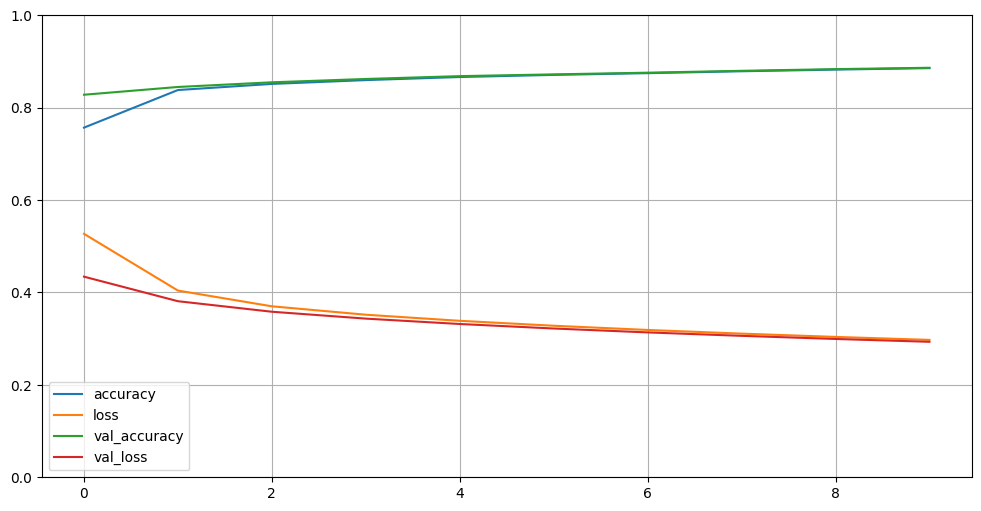

In [ ]:
pd.DataFrame(history2.history).plot(figsize=(12, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict2=predict_df.to_numpy().astype('float64')
data_predict2

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result2=model2.predict(data_predict2)
result2

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.5479662 ],
       [0.8649607 ],
       [0.62438905],
       ...,
       [0.10812049],
       [0.2910296 ],
       [0.38452062]], dtype=float32)

In [ ]:
pre2=result2.round(0).astype('int')
pre2

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre2)

0.48752694795195567

In [ ]:
model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Dense(27, activation="relu"))
model3.add(tf.keras.layers.Dense(20, activation="relu"))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model3.compile(
    loss="binary_crossentropy",
    optimizer='adadelta',
    metrics=["accuracy"])

In [ ]:
history3 = model3.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4518 - loss: 0.7911 - val_accuracy: 0.4636 - val_loss: 0.7664
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.4740 - loss: 0.7473 - val_accuracy: 0.4881 - val_loss: 0.7281
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.5057 - loss: 0.7132 - val_accuracy: 0.5235 - val_loss: 0.6982
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5429 - loss: 0.6863 - val_accuracy: 0.5629 - val_loss: 0.6741
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5810 - loss: 0.6643 - val_accuracy: 0.5987 - val_loss: 0.6540
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6171 - loss: 0.6456 - val_accuracy: 0.6326 - val_loss: 0.6366
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6505 - loss: 0.6291 - val_accuracy: 0.6638 - val_loss: 0.6210
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6785 - loss: 0.6142

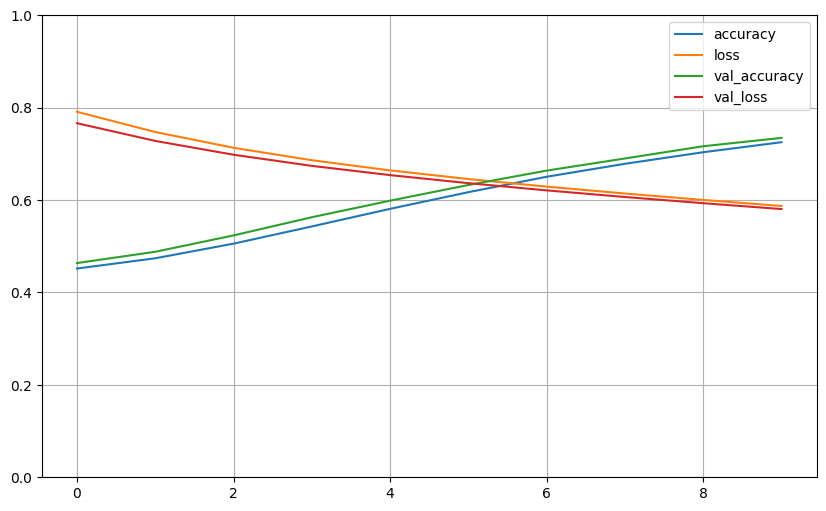

In [ ]:
pd.DataFrame(history3.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict3=predict_df.to_numpy().astype('float64')
data_predict3

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result3=model3.predict(data_predict3)
result3

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.5356051 ],
       [0.6835672 ],
       [0.7693384 ],
       ...,
       [0.76435184],
       [0.69309264],
       [0.68932563]], dtype=float32)

In [ ]:
pre3=result3.round(0).astype('int')
pre3

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre3)

0.46304280874653525

In [ ]:
model4 = tf.keras.models.Sequential()
model4.add(tf.keras.layers.Dense(27, activation="relu"))
model4.add(tf.keras.layers.Dense(20, activation="relu"))
model4.add(tf.keras.layers.Dense(10, activation="relu"))
model4.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model4.compile(
    loss="binary_crossentropy",
    optimizer='adadelta',
    metrics=["accuracy"])

In [ ]:
history4 = model4.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.5909 - loss: 0.6800 - val_accuracy: 0.6061 - val_loss: 0.6736
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6234 - loss: 0.6680 - val_accuracy: 0.6356 - val_loss: 0.6619
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6539 - loss: 0.6564 - val_accuracy: 0.6671 - val_loss: 0.6505
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6838 - loss: 0.6449 - val_accuracy: 0.6970 - val_loss: 0.6390
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7109 - loss: 0.6332 - val_accuracy: 0.7233 - val_loss: 0.6271
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7339 - loss: 0.6211 - val_accuracy: 0.7421 - val_loss: 0.6149
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7529 - loss: 0.6086 - val_accuracy: 0.7615 - val_loss: 0.6023
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7679 - loss: 0.595

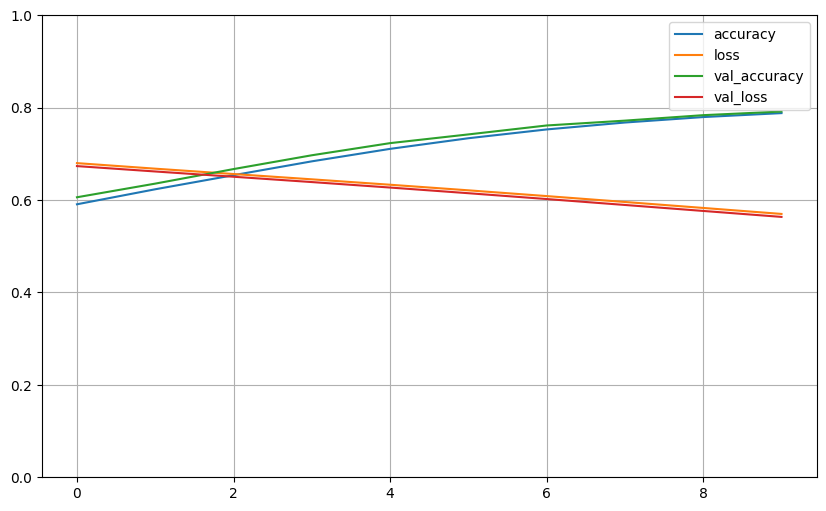

In [ ]:
pd.DataFrame(history4.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict4=predict_df.to_numpy().astype('float64')
data_predict4

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result4=model4.predict(data_predict4)
result4

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.6716828 ],
       [0.554043  ],
       [0.4714196 ],
       ...,
       [0.36066517],
       [0.23288421],
       [0.35193855]], dtype=float32)

In [ ]:
pre4=result4.round(0).astype('int')
pre4

array([[1],
       [1],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre4)

0.5873498614105328

In [ ]:
model5 = tf.keras.models.Sequential()
model5.add(tf.keras.layers.Dense(27, activation="relu"))
model5.add(tf.keras.layers.Dense(20, activation="relu"))
model5.add(tf.keras.layers.Dense(10, activation="relu"))
model5.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model5.compile(
    loss="binary_crossentropy",
    optimizer='adadelta',
    metrics=["accuracy"])

In [ ]:
histors5 = model5.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5846 - loss: 0.6861 - val_accuracy: 0.5924 - val_loss: 0.6809
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.6060 - loss: 0.6733 - val_accuracy: 0.6153 - val_loss: 0.6684
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.6297 - loss: 0.6614 - val_accuracy: 0.6398 - val_loss: 0.6566
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6557 - loss: 0.6501 - val_accuracy: 0.6670 - val_loss: 0.6454
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6802 - loss: 0.6391 - val_accuracy: 0.6891 - val_loss: 0.6344
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7006 - loss: 0.6284 - val_accuracy: 0.7078 - val_loss: 0.6236
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7170 - loss: 0.6177 - val_accuracy: 0.7233 - val_loss: 0.6128
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7295 - loss: 0.60

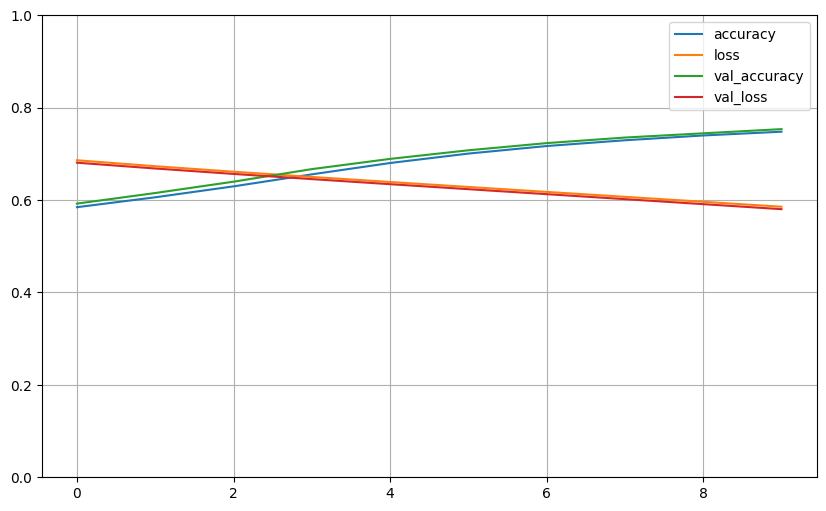

In [ ]:
pd.DataFrame(histors5.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict5=predict_df.to_numpy().astype('float64')
data_predict5

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result5=model5.predict(data_predict5)
result5

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.41357997],
       [0.67735624],
       [0.4815759 ],
       ...,
       [0.46334407],
       [0.5370079 ],
       [0.53410655]], dtype=float32)

In [ ]:
pre5=result5.round(0).astype('int')
pre5

array([[0],
       [1],
       [0],
       ...,
       [0],
       [1],
       [1]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre5)

0.4889898367724053

In [ ]:
model6 = tf.keras.models.Sequential()
model6.add(tf.keras.layers.Dense(27, activation="relu"))
model6.add(tf.keras.layers.Dense(20, activation="relu"))
model6.add(tf.keras.layers.Dense(10, activation="relu"))
model6.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model6.compile(
    loss="binary_crossentropy",
    optimizer='Adam',
    metrics=["accuracy"])

In [ ]:
history6 = model6.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8971 - loss: 0.2620 - val_accuracy: 0.9251 - val_loss: 0.1978
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9276 - loss: 0.1941 - val_accuracy: 0.9323 - val_loss: 0.1678
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9236 - loss: 0.2008 - val_accuracy: 0.9345 - val_loss: 0.1719
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9306 - loss: 0.1715 - val_accuracy: 0.9286 - val_loss: 0.1685
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9368 - loss: 0.1525 - val_accuracy: 0.9449 - val_loss: 0.1379
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9388 - loss: 0.1503 - val_accuracy: 0.9438 - val_loss: 0.1402
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9447 - loss: 0.1402 - val_accuracy: 0.9476 - val_loss: 0.1278
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9465 - loss: 0.1383

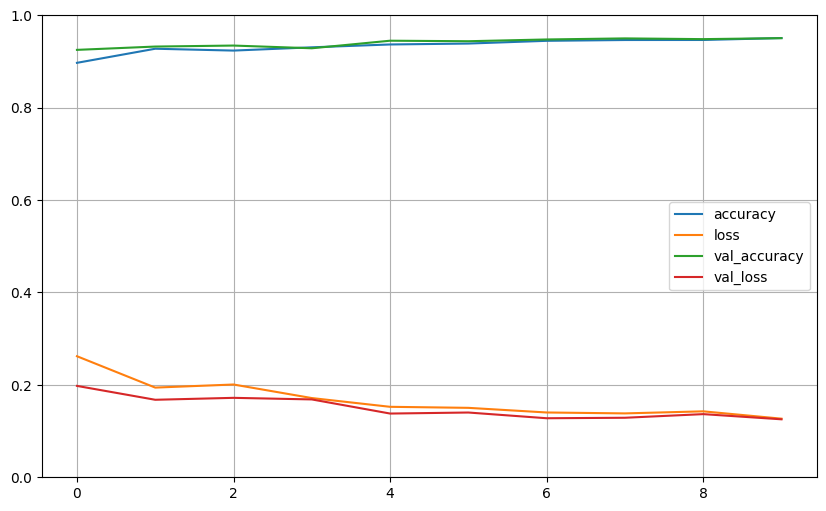

In [ ]:
pd.DataFrame(history6.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict6=predict_df.to_numpy().astype('float64')
data_predict6

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result6=model6.predict(data_predict6)
result6

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.32533672],
       [5.762344  ],
       [7.981619  ],
       ...,
       [0.        ],
       [0.02338248],
       [0.        ]], dtype=float32)

In [ ]:
pre6=result6.round(0).astype('int')
pre6

array([[0],
       [6],
       [8],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre6)

0.2651293501693871

In [ ]:
model7 = tf.keras.models.Sequential()
model7.add(tf.keras.layers.Dense(27, activation="relu"))
model7.add(tf.keras.layers.Dense(20, activation="relu"))
model7.add(tf.keras.layers.Dense(10, activation="relu"))
model7.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model7.compile(
    loss="binary_crossentropy",
    optimizer='adagrad',
    metrics=["accuracy"])

In [ ]:
history7 = model7.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5550 - loss: 0.9456 - val_accuracy: 0.5603 - val_loss: 0.7872
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5682 - loss: 0.7593 - val_accuracy: 0.5772 - val_loss: 0.7353
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.5837 - loss: 0.7272 - val_accuracy: 0.5916 - val_loss: 0.7109
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5986 - loss: 0.7051 - val_accuracy: 0.6064 - val_loss: 0.6895
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6137 - loss: 0.6859 - val_accuracy: 0.6203 - val_loss: 0.6705
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6282 - loss: 0.6706 - val_accuracy: 0.6338 - val_loss: 0.6554
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6430 - loss: 0.6570 - val_accuracy: 0.6494 - val_loss: 0.6425
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6566 - loss: 0.644

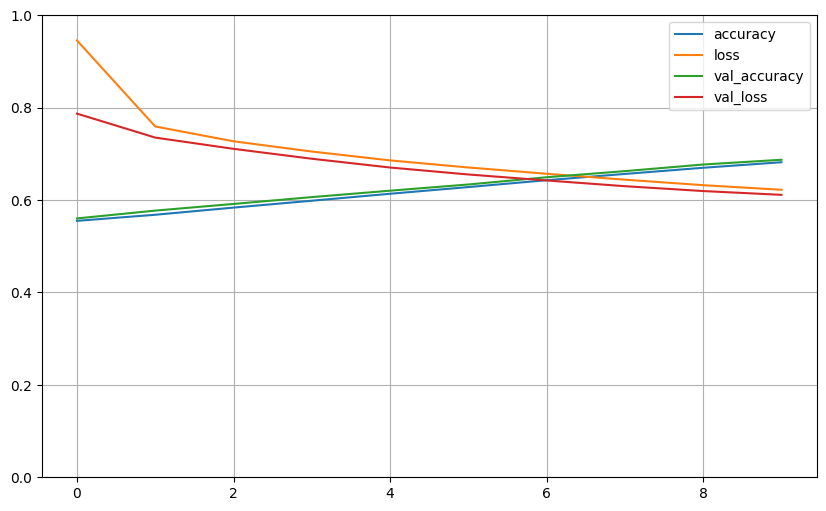

In [ ]:
pd.DataFrame(history7.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict7=predict_df.to_numpy().astype('float64')
data_predict7

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result7=model7.predict(data_predict7)
result7

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.6022471 ],
       [0.44068038],
       [0.        ],
       ...,
       [0.07618532],
       [0.17133999],
       [0.07445265]], dtype=float32)

In [ ]:
pre7=result7.round(0).astype('int')
pre7

array([[1],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre7)

0.5746843239913767

In [ ]:
model8 = tf.keras.models.Sequential()
model8.add(tf.keras.layers.Dense(27, activation="relu"))
model8.add(tf.keras.layers.Dense(20, activation="relu"))
model8.add(tf.keras.layers.Dense(10, activation="relu"))
model8.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model8.compile(
    loss="binary_crossentropy",
    optimizer='adadelta',
    metrics=["accuracy"])

In [ ]:
history8 = model8.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.6077 - loss: 1.4043 - val_accuracy: 0.6072 - val_loss: 1.3745
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.6135 - loss: 1.3369 - val_accuracy: 0.6137 - val_loss: 1.3203
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6195 - loss: 1.2671 - val_accuracy: 0.6211 - val_loss: 1.2487
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6262 - loss: 1.2023 - val_accuracy: 0.6274 - val_loss: 1.1795
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6333 - loss: 1.1407 - val_accuracy: 0.6348 - val_loss: 1.1101
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6395 - loss: 1.0812 - val_accuracy: 0.6411 - val_loss: 1.0623
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6458 - loss: 1.0320 - val_accuracy: 0.6471 - val_loss: 1.0049
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6519 - loss: 0.979

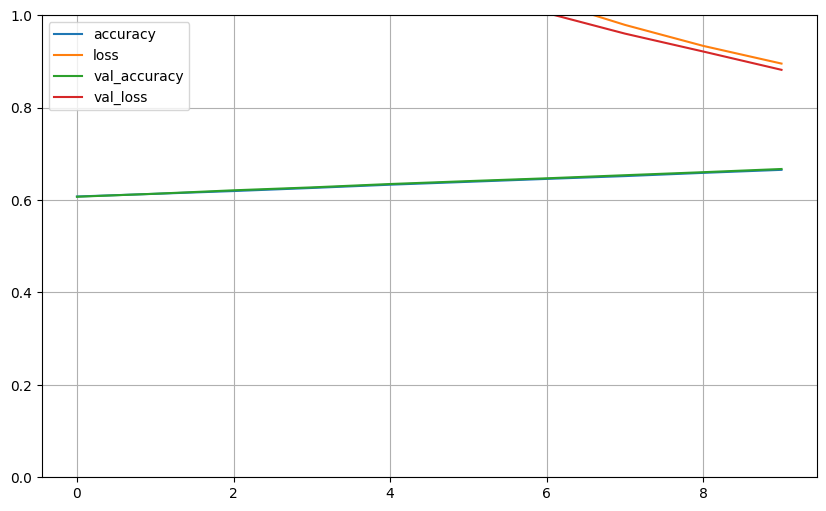

In [ ]:
pd.DataFrame(history8.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict8=predict_df.to_numpy().astype('float64')
data_predict8

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result8= model8.predict(data_predict8)
result8

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.6849913 ],
       [0.2798656 ],
       [0.0780309 ],
       ...,
       [0.982032  ],
       [0.94821316],
       [0.22105823]], dtype=float32)

In [ ]:
pre8=result8.round(0).astype('int')
pre8

array([[1],
       [0],
       [0],
       ...,
       [1],
       [1],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre8)

0.5361487526947952

In [ ]:
model9 = tf.keras.models.Sequential()
model9.add(tf.keras.layers.Dense(27, activation="relu"))
model9.add(tf.keras.layers.Dense(20, activation="relu"))
model9.add(tf.keras.layers.Dense(10, activation="relu"))
model9.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model9.compile(
    loss="binary_crossentropy",
    optimizer='adamax',
    metrics=["accuracy"])

In [ ]:
history9 = model9.fit(
    x_train_model,y_train,validation_data=(x_valid_model, y_valid),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8027 - loss: 0.6610 - val_accuracy: 0.8207 - val_loss: 0.5298
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8391 - loss: 0.4700 - val_accuracy: 0.8521 - val_loss: 0.4322
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.8637 - loss: 0.3862 - val_accuracy: 0.8736 - val_loss: 0.3702
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8779 - loss: 0.3448 - val_accuracy: 0.8839 - val_loss: 0.3484
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8876 - loss: 0.3220 - val_accuracy: 0.8933 - val_loss: 0.3257
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8957 - loss: 0.3007 - val_accuracy: 0.8971 - val_loss: 0.3059
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9004 - loss: 0.2861 - val_accuracy: 0.9027 - val_loss: 0.2865
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9039 - loss: 0.2725

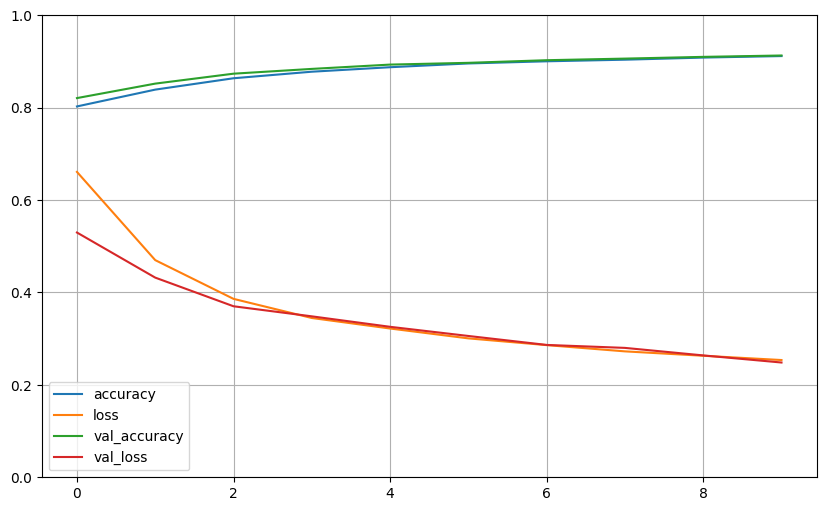

In [ ]:
pd.DataFrame(history9.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict9=predict_df.to_numpy().astype('float64')
data_predict9

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  0.        ,
         1.        ,  0.        ],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27888604, -0.99972919, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ...,  0.        ,
         1.        ,  0.        ],
       [-1.67561721, -0.06185432,  0.20322292, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.17579492, -0.9275078 , -0.54993143, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
result9= model9.predict(data_predict8)
result9

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.21590634],
       [1.048548  ],
       [0.7847262 ],
       ...,
       [0.2352588 ],
       [0.24606828],
       [0.04324577]], dtype=float32)

In [ ]:
pre9=result9.round(0).astype('int')
pre9

array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre9)

0.49337850323375426

## 10.1. Tổng hợp nhanh kết quả của nhánh có xử lý outlier

Theo output hiện có của notebook, độ chính xác của các mô hình ở nhánh này như sau:

| Mô hình | Cấu hình chính | Accuracy |
|---|---|---:|
| Model 1 | `Adam` + output `sigmoid` | 0.3820 |
| Model 2 | `Adagrad` + output `sigmoid` | 0.4875 |
| Model 3 | `Adadelta` + output `sigmoid` | 0.4630 |
| Model 4 | `Adadelta` + output `sigmoid` | **0.5873** |
| Model 5 | `Adadelta` + output `sigmoid` | 0.4890 |
| Model 6 | `Adam` + output `relu` | 0.2651 |
| Model 7 | `Adagrad` + output `relu` | 0.5747 |
| Model 8 | `Adadelta` + output `relu` | 0.5361 |
| Model 9 | `Adamax` + output `relu` | 0.4934 |

Nhìn chung, nhánh có xử lý outlier cho kết quả chưa thật sự cao ở nhiều cấu hình.  
Trong nhóm mô hình này, **Model 4** và **Model 7** là hai cấu hình cho kết quả tốt hơn tương đối, trong khi các mô hình có output `relu` nhìn chung không ổn định bằng output `sigmoid`.

## 11. Nhánh thực nghiệm không xử lý outlier

Sau nhánh đầu tiên, nhóm tiếp tục xây dựng một nhánh khác **không xử lý outlier** để so sánh ảnh hưởng của bước clipping theo IQR.  
Mục tiêu là xem khi giữ nguyên dữ liệu gốc, hiệu năng của mô hình Neural Network thay đổi như thế nào.

> Ở nhánh này, biến `Class` vẫn được giữ theo cách biểu diễn **One-Hot Encoding** để đảm bảo đúng tinh thần của hướng xử lý 2.

In [ ]:
data = pd.read_csv('/content/train.csv')
data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
data["Arrival Delay in Minutes"].fillna(-1, inplace=True)

/tmp/ipykernel_1185/3406163739.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Arrival Delay in Minutes"].fillna(-1, inplace=True)


In [ ]:
data.drop(["Unnamed: 0","id"], axis=1, inplace=True)

In [ ]:
X1 = data.drop("satisfaction", axis=1)
taget1 = data["satisfaction"]

In [ ]:
taget1

,satisfaction
0,neutral or dissatisfied
1,neutral or dissatisfied
2,satisfied
3,neutral or dissatisfied
4,satisfied
...,...
103899,neutral or dissatisfied
103900,satisfied
103901,neutral or dissatisfied
103902,neutral or dissatisfied


In [ ]:
from sklearn.model_selection import train_test_split
X_train1, X_valid1, y_train1, y_valid1 = train_test_split(
    X, y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train1 = le.fit_transform(y_train1)
y_valid1 = le.transform(y_valid1)

## 12. One-Hot Encoding và chuẩn hóa cho nhánh không xử lý outlier

Quy trình tiền xử lý ở nhánh thứ hai vẫn gồm:

- mã hóa các biến phân loại bằng **One-Hot Encoding**
- chuẩn hóa các biến số bằng **StandardScaler**
- ghép toàn bộ đặc trưng đã xử lý thành đầu vào cho mô hình

Nhờ đó, sự khác biệt giữa hai nhánh chủ yếu đến từ việc **có hoặc không xử lý outlier**.

In [ ]:
Mall_airline1=X_train1[["Gender", "Customer Type", "Type of Travel", "Class"]]
df_1hot=encoder.fit_transform(Mall_airline1)
df_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 332492 stored elements and shape (83123, 9)>

In [ ]:
mall1 = pd.DataFrame.sparse.from_spmatrix(df_1hot,
                                                 columns=encoder.get_feature_names_out(),index=X_train1.index)
mall1

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
20921,1.0,0,1.0,0,0,1.0,0,1.0,0
36897,1.0,0,0,1.0,1.0,0,1.0,0,0
8468,0,1.0,1.0,0,0,1.0,0,1.0,0
53490,1.0,0,1.0,0,0,1.0,0,1.0,0
78687,1.0,0,0,1.0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...
54886,0,1.0,0,1.0,1.0,0,0,1.0,0
76820,0,1.0,1.0,0,0,1.0,0,1.0,0
103694,0,1.0,1.0,0,1.0,0,0,1.0,0
860,1.0,0,1.0,0,1.0,0,0,1.0,0


In [ ]:
Mall_airline_valid1=X_valid1[["Gender", "Customer Type", "Type of Travel", "Class"]]
Airline_valid1_1hot=encoder.transform(Mall_airline_valid1)
Airline_valid1_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 83124 stored elements and shape (20781, 9)>

In [ ]:
mall_valid1 = pd.DataFrame.sparse.from_spmatrix(Airline_valid_1hot,
                                                 columns=encoder.get_feature_names_out(),index=X_valid1.index)
mall_valid1

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
80638,1.0,0,1.0,0,0,1.0,0,1.0,0
43398,0,1.0,1.0,0,1.0,0,1.0,0,0
32751,1.0,0,1.0,0,0,1.0,0,1.0,0
33571,1.0,0,1.0,0,0,1.0,0,1.0,0
71287,0,1.0,0,1.0,1.0,0,1.0,0,0
...,...,...,...,...,...,...,...,...,...
8158,0,1.0,0,1.0,1.0,0,1.0,0,0
53718,0,1.0,1.0,0,0,1.0,0,1.0,0
33319,0,1.0,1.0,0,0,1.0,0,1.0,0
99162,1.0,0,1.0,0,1.0,0,1.0,0,0


In [ ]:
data2 = predicted[["Gender", "Customer Type", "Type of Travel", "Class"]]
Airline_test_1hot1=encoder.transform(data2)
Airline_test_1hot1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 103904 stored elements and shape (25976, 9)>

In [ ]:
mall_test = pd.DataFrame.sparse.from_spmatrix(Airline_test_1hot1,
                                                 columns=encoder.get_feature_names_out(),index=predicted.index)
mall_test

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,1.0,0,1.0,0,1.0,0,0,1.0,0
1,1.0,0,1.0,0,1.0,0,1.0,0,0
2,0,1.0,0,1.0,1.0,0,0,1.0,0
3,0,1.0,1.0,0,1.0,0,1.0,0,0
4,1.0,0,1.0,0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...
25971,0,1.0,0,1.0,1.0,0,1.0,0,0
25972,0,1.0,1.0,0,1.0,0,1.0,0,0
25973,1.0,0,1.0,0,0,1.0,0,1.0,0
25974,0,1.0,1.0,0,1.0,0,1.0,0,0


In [ ]:
data_scale1=X_train1.drop(["Gender", "Customer Type", "Type of Travel", "Class"],axis=1)
data_scale1

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,59,1046,4,5,4,1,5,4,5,2,2,4,3,5,2,4,12,3.0
36897,40,752,4,4,4,2,1,4,5,1,4,2,4,3,5,1,19,29.0
8468,65,383,2,3,2,1,1,2,1,1,5,4,5,5,5,1,0,0.0
53490,70,2239,3,5,3,4,3,5,4,5,5,3,5,3,5,5,0,0.0
78687,25,1358,2,2,2,3,1,2,1,1,1,2,3,5,2,1,3,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,39,637,3,5,3,5,3,3,3,3,4,3,2,3,2,3,1,0.0
76820,17,646,3,4,3,1,3,3,2,3,5,1,2,4,4,3,0,2.0
103694,46,1197,1,2,2,2,1,1,1,4,3,3,3,1,1,1,260,263.0
860,37,320,5,5,5,5,5,5,5,5,1,2,4,1,3,5,0,0.0


In [ ]:
std_scaler1=StandardScaler()
num_scale1 = std_scaler1.fit_transform(data_scale)
num_scale1

array([[ 1.29986657, -0.14310337,  0.95637727, ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 0.04355119, -0.43800734,  0.95637727, ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 1.69659774, -0.80814191, -0.54993143, ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.44028236,  0.00836091, -1.30308577, ..., -1.74028074,
         6.36841631,  6.36599827],
       [-0.15481439, -0.87133562,  1.70953161, ...,  1.31011424,
        -0.38581206, -0.38942783],
       [-1.67561721, -0.8402403 ,  0.95637727, ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
scaled_k1=pd.DataFrame(num_scale,
                      columns=std_scaler1.get_feature_names_out(),index=X_train1.index)
scaled_k1

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,1.299867,-0.143103,0.956377,1.271553,0.887405,-1.549472,1.354730,0.558180,1.185329,-1.017279,-1.074922,0.491774,-0.532883,1.339119,-1.395033,0.547515,-0.074078,-0.312370
36897,0.043551,-0.438007,0.956377,0.616850,0.887405,-0.766108,-1.658287,0.558180,1.185329,-1.768222,0.478625,-1.029881,0.313521,-0.241843,1.157994,-1.740281,0.107766,0.355467
8468,1.696598,-0.808142,-0.549931,-0.037854,-0.542403,-1.549472,-1.658287,-0.923888,-1.846677,-1.768222,1.255399,0.491774,1.159924,1.339119,1.157994,-1.740281,-0.385812,-0.389428
53490,2.027207,1.053565,0.203223,1.271553,0.172501,0.800620,-0.151778,1.299214,0.427327,1.235552,1.255399,-0.269054,1.159924,-0.241843,1.157994,1.310114,-0.385812,-0.389428
78687,-0.948277,0.169856,-0.549931,-0.692557,-0.542403,0.017256,-1.658287,-0.923888,-1.846677,-1.768222,-1.851695,-1.029881,-0.532883,1.339119,-1.395033,-1.740281,-0.307879,-0.004137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,-0.022571,-0.553361,0.203223,1.271553,0.172501,1.583984,-0.151778,-0.182854,-0.330674,-0.266335,0.478625,-0.269054,-1.379287,-0.241843,-1.395033,-0.215083,-0.359834,-0.389428
76820,-1.477252,-0.544333,0.203223,0.616850,0.172501,-1.549472,-0.151778,-0.182854,-1.088676,-0.266335,1.255399,-1.790709,-1.379287,0.548638,0.306985,-0.215083,-0.385812,-0.338056
103694,0.440282,0.008361,-1.303086,-0.692557,-0.542403,-0.766108,-1.658287,-1.664922,-1.846677,0.484609,-0.298148,-0.269054,-0.532883,-1.822805,-2.246042,-1.740281,6.368416,6.365998
860,-0.154814,-0.871336,1.709532,1.271553,1.602309,1.583984,1.354730,1.299214,1.185329,1.235552,-1.851695,-1.029881,0.313521,-1.822805,-0.544024,1.310114,-0.385812,-0.389428


In [ ]:
valid_scale1=X_valid1.drop(["Gender", "Customer Type", "Type of Travel", "Class"],axis=1)
valid_scale1

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
80638,26,861,2,4,2,5,5,2,5,5,5,4,4,3,5,5,0,0.0
43398,22,393,3,5,5,5,3,3,3,3,1,1,3,2,3,3,0,16.0
32751,59,196,1,3,1,3,2,3,3,4,4,1,4,3,4,4,37,34.0
33571,32,1020,2,3,2,4,4,2,4,4,3,2,4,1,4,4,27,4.0
71287,35,1117,2,2,2,1,2,2,5,2,2,2,3,2,2,2,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,42,236,1,1,1,3,1,1,1,1,2,3,4,2,4,1,0,0.0
53718,14,558,2,4,2,2,5,2,5,5,4,4,5,5,4,5,0,0.0
33319,9,1005,2,5,2,3,5,2,5,5,4,4,2,3,5,5,1,0.0
99162,45,3234,3,3,3,3,5,5,5,4,4,4,4,3,4,3,0,19.0


In [ ]:
num_scale_valid1 = std_scaler1.transform(valid_scale1)
num_scale_valid1

array([[-0.88215487, -0.32867219, -0.54993143, ...,  1.31011424,
        -0.38581206, -0.38942783],
       [-1.14664232, -0.79811117,  0.20322292, ..., -0.21508325,
        -0.38581206,  0.02154866],
       [ 1.29986657, -0.99571689, -1.30308577, ...,  0.54751549,
         0.5753666 ,  0.48389722],
       ...,
       [-2.00622652, -0.18422943, -0.54993143, ...,  1.31011424,
        -0.35983426, -0.38942783],
       [ 0.3741605 ,  2.05162413,  0.20322292, ..., -0.21508325,
        -0.38581206,  0.09860676],
       [-0.55154556, -1.10605511,  0.95637727, ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
scaled_valid1=pd.DataFrame(num_scale_valid1,
                      columns=std_scaler1.get_feature_names_out(),index=X_valid1.index)
scaled_valid1

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
80638,-0.882155,-0.328672,-0.549931,0.616850,-0.542403,1.583984,1.354730,-0.923888,1.185329,1.235552,1.255399,0.491774,0.313521,-0.241843,1.157994,1.310114,-0.385812,-0.389428
43398,-1.146642,-0.798111,0.203223,1.271553,1.602309,1.583984,-0.151778,-0.182854,-0.330674,-0.266335,-1.851695,-1.790709,-0.532883,-1.032324,-0.544024,-0.215083,-0.385812,0.021549
32751,1.299867,-0.995717,-1.303086,-0.037854,-1.257307,0.017256,-0.905032,-0.182854,-0.330674,0.484609,0.478625,-1.790709,0.313521,-0.241843,0.306985,0.547515,0.575367,0.483897
33571,-0.485424,-0.169183,-0.549931,-0.037854,-0.542403,0.800620,0.601476,-0.923888,0.427327,0.484609,-0.298148,-1.029881,0.313521,-1.822805,0.306985,0.547515,0.315589,-0.286684
71287,-0.287058,-0.071885,-0.549931,-0.692557,-0.542403,-1.549472,-0.905032,-0.923888,1.185329,-1.017279,-1.074922,-1.029881,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,0.175795,-0.955594,-1.303086,-1.347261,-1.257307,0.017256,-1.658287,-1.664922,-1.846677,-1.768222,-1.074922,-0.269054,0.313521,-1.032324,0.306985,-1.740281,-0.385812,-0.389428
53718,-1.675617,-0.632604,-0.549931,0.616850,-0.542403,-0.766108,1.354730,-0.923888,1.185329,1.235552,0.478625,0.491774,1.159924,1.339119,0.306985,1.310114,-0.385812,-0.389428
33319,-2.006227,-0.184229,-0.549931,1.271553,-0.542403,0.017256,1.354730,-0.923888,1.185329,1.235552,0.478625,0.491774,-1.379287,-0.241843,1.157994,1.310114,-0.359834,-0.389428
99162,0.374161,2.051624,0.203223,-0.037854,0.172501,0.017256,1.354730,1.299214,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,-0.215083,-0.385812,0.098607


In [ ]:
test_scale1=predicted.drop(["Gender", "Customer Type", "Type of Travel", "Class"],axis=1)
test_scale1

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,52,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0
1,36,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0
2,20,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0
3,44,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0
4,49,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,34,526,3,3,3,1,4,3,4,4,3,2,4,4,5,4,0,0.0
25972,23,646,4,4,4,4,4,4,4,4,4,5,5,5,5,4,0,0.0
25973,17,828,2,5,1,5,2,1,2,2,4,3,4,5,4,2,0,0.0
25974,14,1127,3,3,3,3,4,4,4,4,3,2,5,4,5,4,0,0.0


In [ ]:
num_scale_test1 = std_scaler1.transform(test_scale1)
num_scale_test1

array([[ 0.83701353, -1.03182758,  1.70953161, ...,  1.31011424,
         0.91307801,  0.74075753],
       [-0.22093625,  1.67948341, -1.30308577, ...,  1.31011424,
        -0.38581206, -0.38942783],
       [-1.27888604, -0.99972919, -0.54993143, ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [-1.47725163, -0.36177366, -0.54993143, ..., -0.97768199,
        -0.38581206, -0.38942783],
       [-1.67561721, -0.06185432,  0.20322292, ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 0.17579492, -0.9275078 , -0.54993143, ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
scaled_test1=pd.DataFrame(num_scale_test1,
                      columns=std_scaler1.get_feature_names_out(),index=predicted.index)
scaled_test1

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0.837014,-1.031828,1.709532,0.616850,0.172501,0.800620,-0.151778,0.558180,-0.330674,1.235552,1.255399,1.252602,1.159924,-1.032324,1.157994,1.310114,0.913078,0.740758
1,-0.220936,1.679483,-1.303086,-1.347261,0.172501,-1.549472,1.354730,0.558180,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,1.310114,-0.385812,-0.389428
2,-1.278886,-0.999729,-0.549931,-2.001964,-0.542403,0.800620,-0.905032,-0.923888,-1.088676,-1.017279,0.478625,-1.790709,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
3,0.308039,2.195064,-2.056240,-2.001964,-1.972211,-0.766108,-0.151778,0.558180,0.427327,-1.768222,-1.851695,-1.790709,-2.225690,-0.241843,-2.246042,0.547515,-0.385812,-0.235312
4,0.638648,-0.006685,-0.549931,-0.037854,0.887405,0.017256,0.601476,-1.664922,-1.088676,-1.017279,-1.074922,-1.029881,-1.379287,0.548638,-1.395033,0.547515,-0.385812,0.124293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,-0.353180,-0.664702,0.203223,-0.037854,0.172501,-1.549472,0.601476,-0.182854,0.427327,0.484609,-0.298148,-1.029881,0.313521,0.548638,1.157994,0.547515,-0.385812,-0.389428
25972,-1.080520,-0.544333,0.956377,0.616850,0.887405,0.800620,0.601476,0.558180,0.427327,0.484609,0.478625,1.252602,1.159924,1.339119,1.157994,0.547515,-0.385812,-0.389428
25973,-1.477252,-0.361774,-0.549931,1.271553,-1.257307,1.583984,-0.905032,-1.664922,-1.088676,-1.017279,0.478625,-0.269054,0.313521,1.339119,0.306985,-0.977682,-0.385812,-0.389428
25974,-1.675617,-0.061854,0.203223,-0.037854,0.172501,0.017256,0.601476,0.558180,0.427327,0.484609,-0.298148,-1.029881,1.159924,0.548638,1.157994,0.547515,-0.385812,-0.389428


In [ ]:
final_df1=pd.concat([mall1,scaled_k1],axis=1,join='inner')
final_df1

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Age,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20921,1.0,0,1.0,0,0,1.0,0,1.0,0,1.299867,...,1.185329,-1.017279,-1.074922,0.491774,-0.532883,1.339119,-1.395033,0.547515,-0.074078,-0.312370
36897,1.0,0,0,1.0,1.0,0,1.0,0,0,0.043551,...,1.185329,-1.768222,0.478625,-1.029881,0.313521,-0.241843,1.157994,-1.740281,0.107766,0.355467
8468,0,1.0,1.0,0,0,1.0,0,1.0,0,1.696598,...,-1.846677,-1.768222,1.255399,0.491774,1.159924,1.339119,1.157994,-1.740281,-0.385812,-0.389428
53490,1.0,0,1.0,0,0,1.0,0,1.0,0,2.027207,...,0.427327,1.235552,1.255399,-0.269054,1.159924,-0.241843,1.157994,1.310114,-0.385812,-0.389428
78687,1.0,0,0,1.0,1.0,0,0,1.0,0,-0.948277,...,-1.846677,-1.768222,-1.851695,-1.029881,-0.532883,1.339119,-1.395033,-1.740281,-0.307879,-0.004137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54886,0,1.0,0,1.0,1.0,0,0,1.0,0,-0.022571,...,-0.330674,-0.266335,0.478625,-0.269054,-1.379287,-0.241843,-1.395033,-0.215083,-0.359834,-0.389428
76820,0,1.0,1.0,0,0,1.0,0,1.0,0,-1.477252,...,-1.088676,-0.266335,1.255399,-1.790709,-1.379287,0.548638,0.306985,-0.215083,-0.385812,-0.338056
103694,0,1.0,1.0,0,1.0,0,0,1.0,0,0.440282,...,-1.846677,0.484609,-0.298148,-0.269054,-0.532883,-1.822805,-2.246042,-1.740281,6.368416,6.365998
860,1.0,0,1.0,0,1.0,0,0,1.0,0,-0.154814,...,1.185329,1.235552,-1.851695,-1.029881,0.313521,-1.822805,-0.544024,1.310114,-0.385812,-0.389428


In [ ]:
valid_df1=pd.concat([mall_valid1,scaled_valid1],axis=1,join='inner')
valid_df1

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Age,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
80638,1.0,0,1.0,0,0,1.0,0,1.0,0,-0.882155,...,1.185329,1.235552,1.255399,0.491774,0.313521,-0.241843,1.157994,1.310114,-0.385812,-0.389428
43398,0,1.0,1.0,0,1.0,0,1.0,0,0,-1.146642,...,-0.330674,-0.266335,-1.851695,-1.790709,-0.532883,-1.032324,-0.544024,-0.215083,-0.385812,0.021549
32751,1.0,0,1.0,0,0,1.0,0,1.0,0,1.299867,...,-0.330674,0.484609,0.478625,-1.790709,0.313521,-0.241843,0.306985,0.547515,0.575367,0.483897
33571,1.0,0,1.0,0,0,1.0,0,1.0,0,-0.485424,...,0.427327,0.484609,-0.298148,-1.029881,0.313521,-1.822805,0.306985,0.547515,0.315589,-0.286684
71287,0,1.0,0,1.0,1.0,0,1.0,0,0,-0.287058,...,1.185329,-1.017279,-1.074922,-1.029881,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,0,1.0,0,1.0,1.0,0,1.0,0,0,0.175795,...,-1.846677,-1.768222,-1.074922,-0.269054,0.313521,-1.032324,0.306985,-1.740281,-0.385812,-0.389428
53718,0,1.0,1.0,0,0,1.0,0,1.0,0,-1.675617,...,1.185329,1.235552,0.478625,0.491774,1.159924,1.339119,0.306985,1.310114,-0.385812,-0.389428
33319,0,1.0,1.0,0,0,1.0,0,1.0,0,-2.006227,...,1.185329,1.235552,0.478625,0.491774,-1.379287,-0.241843,1.157994,1.310114,-0.359834,-0.389428
99162,1.0,0,1.0,0,1.0,0,1.0,0,0,0.374161,...,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,-0.215083,-0.385812,0.098607


In [ ]:
data3 = pd.concat([mall_test,scaled_test1],axis=1,join='inner')
data3

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Age,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.0,0,1.0,0,1.0,0,0,1.0,0,0.837014,...,-0.330674,1.235552,1.255399,1.252602,1.159924,-1.032324,1.157994,1.310114,0.913078,0.740758
1,1.0,0,1.0,0,1.0,0,1.0,0,0,-0.220936,...,1.185329,0.484609,0.478625,0.491774,0.313521,-0.241843,0.306985,1.310114,-0.385812,-0.389428
2,0,1.0,0,1.0,1.0,0,0,1.0,0,-1.278886,...,-1.088676,-1.017279,0.478625,-1.790709,-0.532883,-1.032324,-1.395033,-0.977682,-0.385812,-0.389428
3,0,1.0,1.0,0,1.0,0,1.0,0,0,0.308039,...,0.427327,-1.768222,-1.851695,-1.790709,-2.225690,-0.241843,-2.246042,0.547515,-0.385812,-0.235312
4,1.0,0,1.0,0,1.0,0,0,1.0,0,0.638648,...,-1.088676,-1.017279,-1.074922,-1.029881,-1.379287,0.548638,-1.395033,0.547515,-0.385812,0.124293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,0,1.0,0,1.0,1.0,0,1.0,0,0,-0.353180,...,0.427327,0.484609,-0.298148,-1.029881,0.313521,0.548638,1.157994,0.547515,-0.385812,-0.389428
25972,0,1.0,1.0,0,1.0,0,1.0,0,0,-1.080520,...,0.427327,0.484609,0.478625,1.252602,1.159924,1.339119,1.157994,0.547515,-0.385812,-0.389428
25973,1.0,0,1.0,0,0,1.0,0,1.0,0,-1.477252,...,-1.088676,-1.017279,0.478625,-0.269054,0.313521,1.339119,0.306985,-0.977682,-0.385812,-0.389428
25974,0,1.0,1.0,0,1.0,0,1.0,0,0,-1.675617,...,0.427327,0.484609,-0.298148,-1.029881,1.159924,0.548638,1.157994,0.547515,-0.385812,-0.389428


## 13. Huấn luyện mô hình Neural Network trên dữ liệu không xử lý outlier

Nhóm tiếp tục thử nhiều cấu hình Neural Network tương tự nhánh trước để so sánh hiệu quả.  
Chỉ số đánh giá chính vẫn là **Accuracy**, kết hợp với các biểu đồ học theo epoch để nhận xét độ ổn định của mô hình.

In [ ]:
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
# Xây dựng model Sequential
model10 = tf.keras.models.Sequential()
model10.add(tf.keras.layers.Dense(27, activation="relu"))
model10.add(tf.keras.layers.Dense(20, activation="relu"))
model10.add(tf.keras.layers.Dense(10, activation="relu"))
model10.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model10.compile(
    loss="binary_crossentropy",
    optimizer='Adam',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
x_valid_model1=valid_df.to_numpy().astype('float64')
x_valid_model1

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ..., -0.21508325,
        -0.38581206,  0.02154866],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
         0.5753666 ,  0.48389722],
       ...,
       [ 0.        ,  1.        ,  1.        , ...,  1.31011424,
        -0.35983426, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -0.21508325,
        -0.38581206,  0.09860676],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history10 = model10.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9116 - loss: 0.2103 - val_accuracy: 0.9373 - val_loss: 0.1516
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9425 - loss: 0.1399 - val_accuracy: 0.9462 - val_loss: 0.1266
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9486 - loss: 0.1233 - val_accuracy: 0.9492 - val_loss: 0.1160
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9527 - loss: 0.1137 - val_accuracy: 0.9516 - val_loss: 0.1102
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9549 - loss: 0.1076 - val_accuracy: 0.9532 - val_loss: 0.1067
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9560 - loss: 0.1040 - val_accuracy: 0.9543 - val_loss: 0.1055
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9568 - loss: 0.1011 - val_accuracy: 0.9550 - val_loss: 0.1023
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9578 - loss: 0.0988

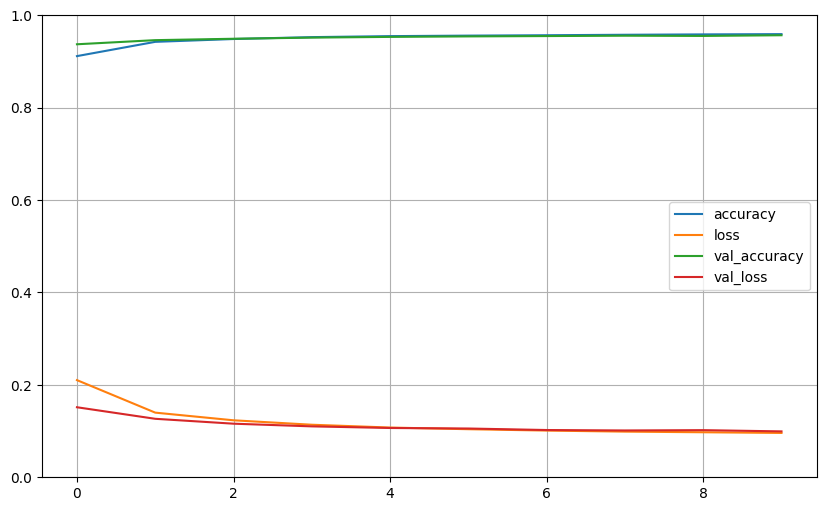

In [ ]:
pd.DataFrame(history10.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict10=data3.to_numpy().astype('float64')
data_predict10

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result10=model10.predict(data_predict10)
result10

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[9.6102273e-01],
       [1.0000000e+00],
       [5.6617515e-04],
       ...,
       [7.3316747e-05],
       [9.9999899e-01],
       [9.2748405e-06]], dtype=float32)

In [ ]:
pre10=result10.round(0).astype('int')
pre10

array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre10)

0.9568062827225131

In [ ]:
# Xây dựng model Sequential
model11 = tf.keras.models.Sequential()
model11.add(tf.keras.layers.Dense(27, activation="relu"))
model11.add(tf.keras.layers.Dense(20, activation="relu"))
model11.add(tf.keras.layers.Dense(10, activation="relu"))
model11.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model11.compile(
    loss="binary_crossentropy",
    optimizer='adagrad',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history11 = model11.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7868 - loss: 0.5012 - val_accuracy: 0.8458 - val_loss: 0.3930
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8546 - loss: 0.3670 - val_accuracy: 0.8618 - val_loss: 0.3469
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8656 - loss: 0.3380 - val_accuracy: 0.8689 - val_loss: 0.3282
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8717 - loss: 0.3229 - val_accuracy: 0.8736 - val_loss: 0.3162
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8754 - loss: 0.3123 - val_accuracy: 0.8780 - val_loss: 0.3069
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8791 - loss: 0.3038 - val_accuracy: 0.8816 - val_loss: 0.2991
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8821 - loss: 0.2964 - val_accuracy: 0.8844 - val_loss: 0.2922
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8848 - loss: 0.289

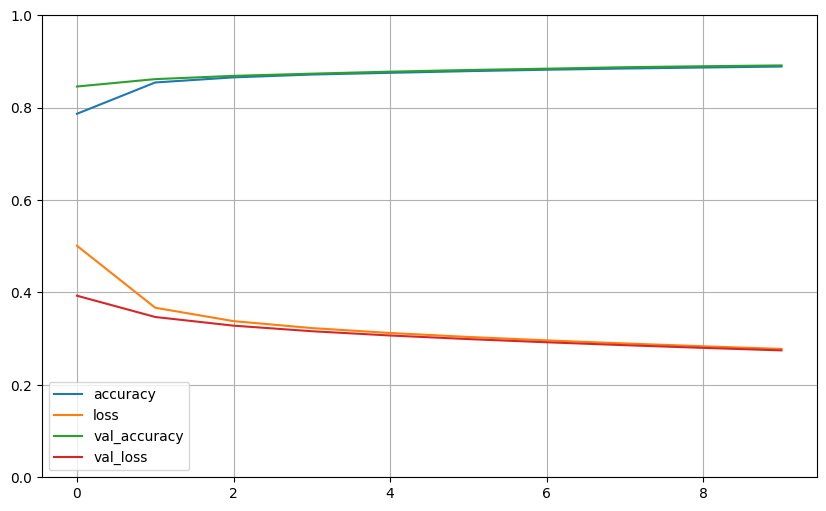

In [ ]:
pd.DataFrame(history11.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict11=data3.to_numpy().astype('float64')
data_predict11

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result11=model11.predict(data_predict11)
result11

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.9133242 ],
       [0.964429  ],
       [0.03820213],
       ...,
       [0.04592713],
       [0.87964016],
       [0.01234765]], dtype=float32)

In [ ]:
pre11=result11.round(0).astype('int')
pre11

array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre11)

0.8882814906067139

In [ ]:
# Xây dựng model Sequential
model12 = tf.keras.models.Sequential()
model12.add(tf.keras.layers.Dense(27, activation="relu"))
model12.add(tf.keras.layers.Dense(20, activation="relu"))
model12.add(tf.keras.layers.Dense(10, activation="relu"))
model12.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model12.compile(
    loss="binary_crossentropy",
    optimizer='adadelta',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history12 = model12.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.6207 - loss: 0.6671 - val_accuracy: 0.6474 - val_loss: 0.6577
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.6708 - loss: 0.6487 - val_accuracy: 0.6930 - val_loss: 0.6396
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7075 - loss: 0.6314 - val_accuracy: 0.7279 - val_loss: 0.6226
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7360 - loss: 0.6151 - val_accuracy: 0.7512 - val_loss: 0.6065
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7562 - loss: 0.5997 - val_accuracy: 0.7665 - val_loss: 0.5912
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7714 - loss: 0.5848 - val_accuracy: 0.7791 - val_loss: 0.5764
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7832 - loss: 0.5704 - val_accuracy: 0.7882 - val_loss: 0.5620
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7912 - loss: 0.556

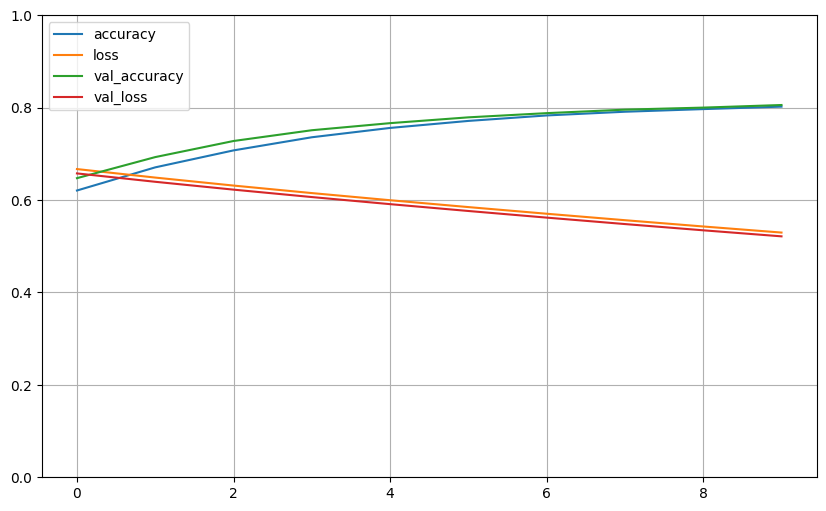

In [ ]:
pd.DataFrame(history12.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict12=data3.to_numpy().astype('float64')
data_predict12

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result12=model12.predict(data_predict12)
result12

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.60764617],
       [0.65344805],
       [0.35429943],
       ...,
       [0.29157346],
       [0.41336495],
       [0.19946471]], dtype=float32)

In [ ]:
pre12=result12.round(0).astype('int')
pre12

array([[1],
       [1],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre12)

0.8007391438250693

In [ ]:
# Xây dựng model Sequential
model13 = tf.keras.models.Sequential()
model13.add(tf.keras.layers.Dense(27, activation="relu"))
model13.add(tf.keras.layers.Dense(20, activation="relu"))
model13.add(tf.keras.layers.Dense(10, activation="relu"))
model13.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [ ]:
model13.compile(
    loss="binary_crossentropy",
    optimizer='adamax',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history13 = model13.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8735 - loss: 0.3097 - val_accuracy: 0.9138 - val_loss: 0.2236
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9198 - loss: 0.2002 - val_accuracy: 0.9268 - val_loss: 0.1831
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9304 - loss: 0.1737 - val_accuracy: 0.9357 - val_loss: 0.1646
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9362 - loss: 0.1595 - val_accuracy: 0.9405 - val_loss: 0.1528
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9399 - loss: 0.1494 - val_accuracy: 0.9430 - val_loss: 0.1439
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9427 - loss: 0.1413 - val_accuracy: 0.9446 - val_loss: 0.1361
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9452 - loss: 0.1345 - val_accuracy: 0.9469 - val_loss: 0.1298
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9473 - loss: 0.1290

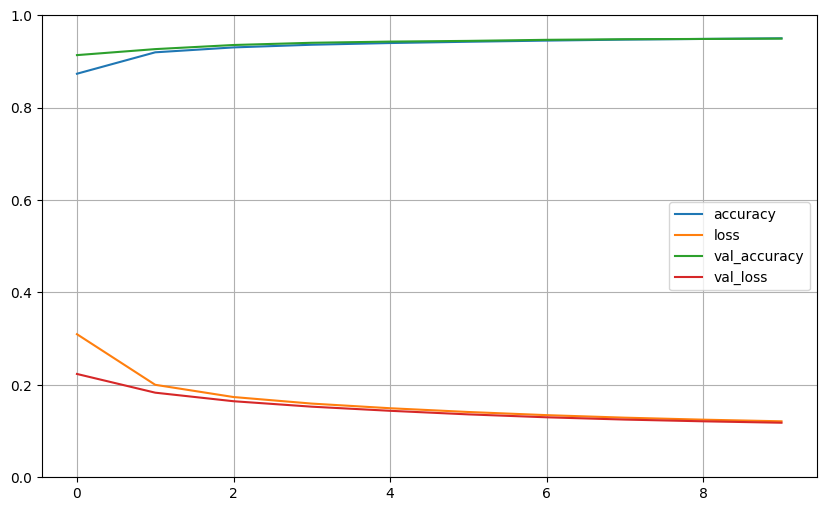

In [ ]:
pd.DataFrame(history13.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict13=data3.to_numpy().astype('float64')
data_predict13

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result13=model13.predict(data_predict13)
result13

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[9.9734473e-01],
       [9.9989390e-01],
       [3.7973678e-05],
       ...,
       [7.3601797e-05],
       [9.9048299e-01],
       [2.6466217e-04]], dtype=float32)

In [ ]:
pre13=result13.round(0).astype('int')
pre13

array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre13)

0.9503002771789344

In [ ]:
# Xây dựng model Sequential
model14 = tf.keras.models.Sequential()
model14.add(tf.keras.layers.Dense(27, activation="relu"))
model14.add(tf.keras.layers.Dense(20, activation="relu"))
model14.add(tf.keras.layers.Dense(10, activation="relu"))
model14.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model14.compile(
    loss="binary_crossentropy",
    optimizer='Adam',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history14 = model14.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8942 - loss: 0.3019 - val_accuracy: 0.9243 - val_loss: 0.2337
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9195 - loss: 0.2237 - val_accuracy: 0.9304 - val_loss: 0.1884
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9333 - loss: 0.1931 - val_accuracy: 0.9281 - val_loss: 0.2080
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9349 - loss: 0.1869 - val_accuracy: 0.9412 - val_loss: 0.1761
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9415 - loss: 0.1697 - val_accuracy: 0.9455 - val_loss: 0.1706
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9422 - loss: 0.1761 - val_accuracy: 0.9429 - val_loss: 0.1695
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9426 - loss: 0.1681 - val_accuracy: 0.9478 - val_loss: 0.1518
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9476 - loss: 0.15

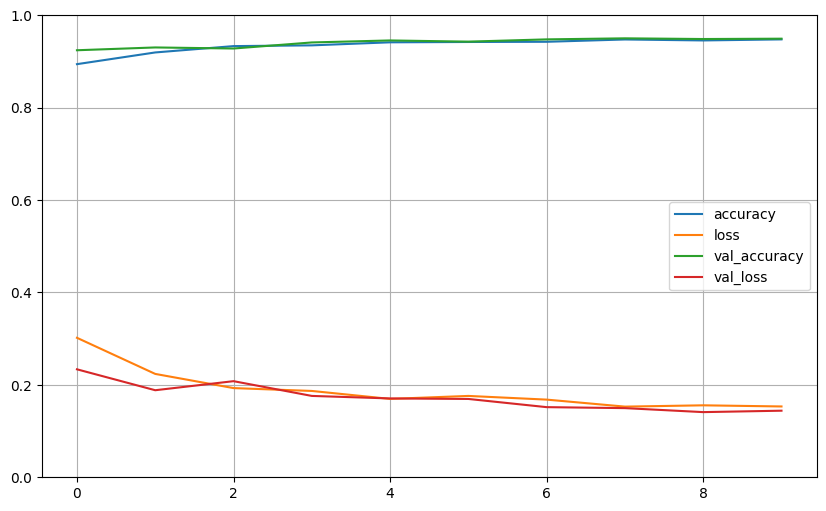

In [ ]:
pd.DataFrame(history14.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict14=data3.to_numpy().astype('float64')
data_predict14

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result14= model14.predict(data_predict14)
result14

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[1.4344349],
       [3.2882607],
       [0.       ],
       ...,
       [0.       ],
       [1.683055 ],
       [0.       ]], dtype=float32)

In [ ]:
pre14=result14.round(0).astype('int')
pre14

array([[1],
       [3],
       [0],
       ...,
       [0],
       [2],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre14)

0.6755851555281799

In [ ]:
# Xây dựng model Sequential
model15 = tf.keras.models.Sequential()
model15.add(tf.keras.layers.Dense(27, activation="relu"))
model15.add(tf.keras.layers.Dense(20, activation="relu"))
model15.add(tf.keras.layers.Dense(10, activation="relu"))
model15.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model15.compile(
    loss="binary_crossentropy",
    optimizer='adagrad',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history15 = model15.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5713 - loss: 2.9506 - val_accuracy: 0.5711 - val_loss: 2.2136
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.5791 - loss: 1.9029 - val_accuracy: 0.5800 - val_loss: 1.6651
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.5859 - loss: 1.5608 - val_accuracy: 0.5878 - val_loss: 1.4163
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5930 - loss: 1.3526 - val_accuracy: 0.5963 - val_loss: 1.2469
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5985 - loss: 1.2200 - val_accuracy: 0.5992 - val_loss: 1.1165
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6039 - loss: 1.0924 - val_accuracy: 0.6064 - val_loss: 1.0396
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6092 - loss: 1.0399 - val_accuracy: 0.6121 - val_loss: 1.0022
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6152 - loss: 0.9989

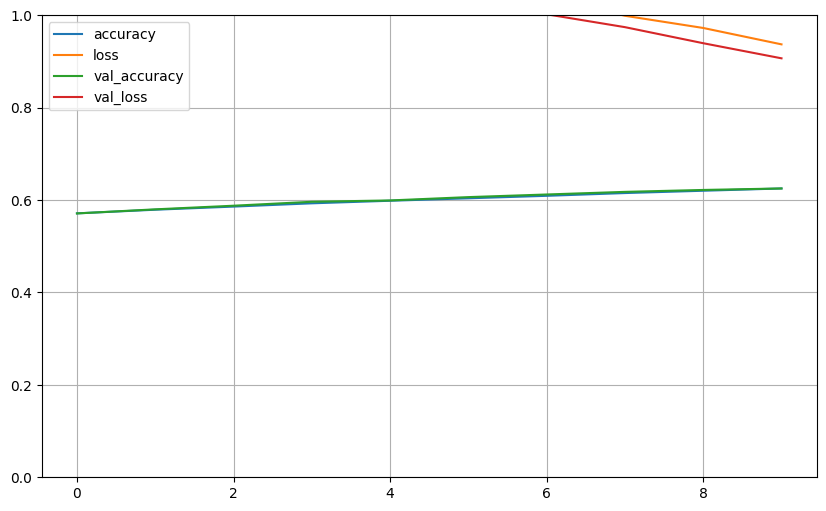

In [ ]:
pd.DataFrame(history15.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict15=data3.to_numpy().astype('float64')
data_predict15

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result15= model15.predict(data_predict15)
result15

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.69728386],
       [0.16222431],
       [0.46413213],
       ...,
       [0.46530142],
       [0.4991513 ],
       [0.62569153]], dtype=float32)

In [ ]:
pre15=result15.round(0).astype('int')
pre15

array([[1],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre15)

0.624153064367108

In [ ]:
# Xây dựng model Sequential
model16 = tf.keras.models.Sequential()
model16.add(tf.keras.layers.Dense(27, activation="relu"))
model16.add(tf.keras.layers.Dense(20, activation="relu"))
model16.add(tf.keras.layers.Dense(10, activation="relu"))
model16.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model16.compile(
    loss="binary_crossentropy",
    optimizer='adadelta',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history16 = model16.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.4389 - loss: 5.7885 - val_accuracy: 0.4417 - val_loss: 5.7683
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.4397 - loss: 5.5974 - val_accuracy: 0.4430 - val_loss: 5.6007
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4408 - loss: 5.4201 - val_accuracy: 0.4433 - val_loss: 5.4177
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4425 - loss: 5.2217 - val_accuracy: 0.4450 - val_loss: 5.2259
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4443 - loss: 5.0156 - val_accuracy: 0.4463 - val_loss: 5.0162
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.4467 - loss: 4.8149 - val_accuracy: 0.4484 - val_loss: 4.8128
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4494 - loss: 4.5986 - val_accuracy: 0.4511 - val_loss: 4.5761
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4523 - loss: 4.

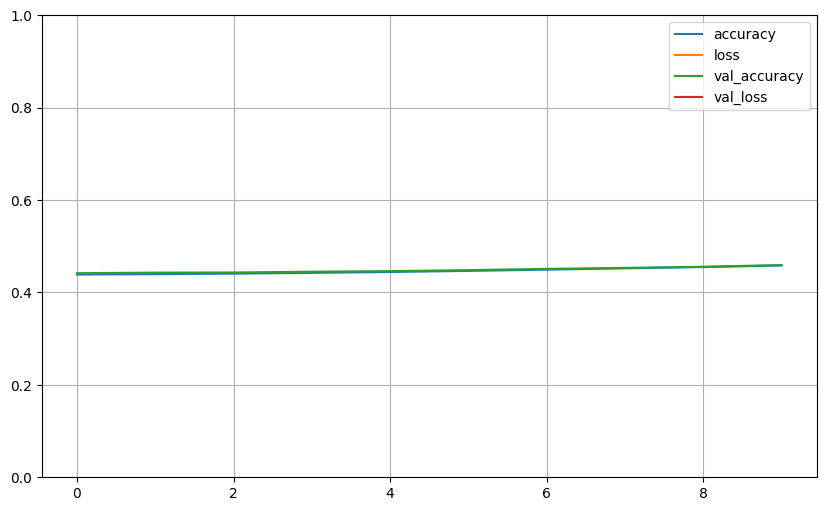

In [ ]:
pd.DataFrame(history16.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict16=data3.to_numpy().astype('float64')
data_predict16

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result16= model16.predict(data_predict16)
result16

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.98901886],
       [0.4006662 ],
       [0.9722257 ],
       ...,
       [1.5456997 ],
       [1.2117628 ],
       [1.2308334 ]], dtype=float32)

In [ ]:
pre16=result16.round(0).astype('int')
pre16

array([[1],
       [0],
       [1],
       ...,
       [2],
       [1],
       [1]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre16)

0.44256236526024023

In [ ]:
# Xây dựng model Sequential
model17 = tf.keras.models.Sequential()
model17.add(tf.keras.layers.Dense(27, activation="relu"))
model17.add(tf.keras.layers.Dense(20, activation="relu"))
model17.add(tf.keras.layers.Dense(10, activation="relu"))
model17.add(tf.keras.layers.Dense(1, activation="relu"))

In [ ]:
model17.compile(
    loss="binary_crossentropy",
    optimizer='adamax',
    metrics=["accuracy"])

In [ ]:
x_train_model1=final_df.to_numpy().astype('float64')
x_train_model1

array([[ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.07407844, -0.31236974],
       [ 1.        ,  0.        ,  0.        , ..., -1.74028074,
         0.10776617,  0.35546707],
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.74028074,
         6.36841631,  6.36599827],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783]])

In [ ]:
history17 = model17.fit(
    x_train_model1,y_train1,validation_data=(x_valid_model1, y_valid1),epochs=10,
    batch_size=32)

Epoch 1/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7509 - loss: 0.7865 - val_accuracy: 0.8192 - val_loss: 0.4553
Epoch 2/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8451 - loss: 0.4123 - val_accuracy: 0.8599 - val_loss: 0.3777
Epoch 3/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8768 - loss: 0.3459 - val_accuracy: 0.8852 - val_loss: 0.3181
Epoch 4/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8918 - loss: 0.2999 - val_accuracy: 0.8962 - val_loss: 0.2831
Epoch 5/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8984 - loss: 0.2800 - val_accuracy: 0.9017 - val_loss: 0.2619
Epoch 6/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9040 - loss: 0.2642 - val_accuracy: 0.9076 - val_loss: 0.2511
Epoch 7/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9071 - loss: 0.2539 - val_accuracy: 0.9113 - val_loss: 0.2390
Epoch 8/10
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9106 - loss: 0.2419 -

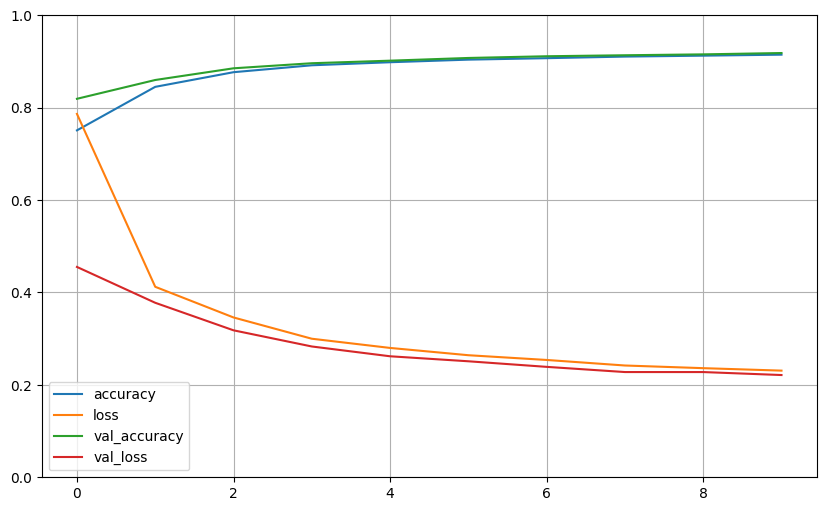

In [ ]:
pd.DataFrame(history17.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
data_predict17=data3.to_numpy().astype('float64')
data_predict17

array([[ 1.        ,  0.        ,  1.        , ...,  1.31011424,
         0.91307801,  0.74075753],
       [ 1.        ,  0.        ,  1.        , ...,  1.31011424,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  0.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.97768199,
        -0.38581206, -0.38942783],
       [ 0.        ,  1.        ,  1.        , ...,  0.54751549,
        -0.38581206, -0.38942783],
       [ 1.        ,  0.        ,  1.        , ..., -1.74028074,
        -0.38581206, -0.38942783]])

In [ ]:
result17= model17.predict(data_predict15)
result17

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[1.0898838],
       [1.528735 ],
       [0.       ],
       ...,
       [0.       ],
       [0.8942279],
       [0.       ]], dtype=float32)

In [ ]:
pre17=result17.round(0).astype('int')
pre17

array([[1],
       [2],
       [0],
       ...,
       [0],
       [1],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_truth,pre17)

0.8437788728056668

## 14. Tổng hợp và đánh giá các mô hình

Với hướng xử lý 2, mục tiêu của nhóm là đánh giá hiệu quả của **Neural Network kết hợp One-Hot Encoding cho biến `Class`**.  
Theo output hiện có của notebook, các mô hình ở nhánh thứ hai cho kết quả như sau:

| Mô hình | Cấu hình chính | Accuracy |
|---|---|---:|
| Model 10 | `Adam` + output `sigmoid` | **0.9568** |
| Model 11 | `Adagrad` + output `sigmoid` | 0.8883 |
| Model 12 | `Adadelta` + output `sigmoid` | 0.8007 |
| Model 13 | `Adamax` + output `sigmoid` | 0.9503 |
| Model 14 | `Adam` + output `relu` | 0.6756 |
| Model 15 | `Adagrad` + output `relu` | 0.6242 |
| Model 16 | `Adadelta` + output `relu` | 0.4426 |
| Model 17 | `Adamax` + output `relu` | 0.8438 |

Từ bảng trên có thể rút ra một số nhận xét:

- **Model 10** là mô hình cho kết quả tốt nhất với accuracy khoảng **95.68%**
- **Model 13** cũng cho kết quả rất cao, khoảng **95.03%**
- Các mô hình dùng **output `sigmoid`** nhìn chung cho kết quả tốt và ổn định hơn so với output `relu`
- Các optimizer như **Adam** và **Adamax** cho hiệu năng nổi bật hơn trong hướng xử lý này

### 14.1. Kết luận

Hướng xử lý 2 cho thấy rằng việc biểu diễn biến `Class` bằng **One-Hot Encoding** hoàn toàn có thể kết hợp hiệu quả với mô hình Neural Network trong bài toán dự đoán `satisfaction`.  
Trong các cấu hình đã thử nghiệm, mô hình dùng **optimizer `Adam`** và **output `sigmoid`** cho kết quả tốt nhất.

Nếu so với hướng xử lý 1, điểm khác biệt cốt lõi của hướng này không nằm ở loại mô hình mà nằm ở **cách mã hóa biến `Class`**.  
Do đó, việc đối chiếu hai hướng xử lý sẽ giúp nhóm đánh giá được mức độ ảnh hưởng của bước tiền xử lý dữ liệu đến hiệu năng dự đoán của Neural Network.